# Modelado de Anomalías — TFG Azure Cloud Security
## Detección de Anomalías en Logs de Azure Storage mediante Machine Learning

**Dataset:** `dataset_final_TFG.csv` (~427k registros, SIN etiquetas)  
**Ground Truth:** `ground_truth_eventos.csv` (solo para evaluación post-entrenamiento)  
**Hardware objetivo:** RTX 3050 Laptop 4GB VRAM + Intel i7 + 16GB RAM  

---

### Modelos implementados (estado del arte 2020-2024)

| Categoría | Modelos | Referencias |
|-----------|---------|-------------|
| Clásicos baseline | Isolation Forest, OCSVM, LOF | Liu et al. 2008; Schölkopf et al. 2001; Breunig et al. 2000 |
| Clásicos mejorados | Extended IF, HBOS | Hariri et al. 2019; Goldstein & Dengel 2012 |
| Deep Learning | Autoencoder, VAE | Hinton 2006; Kingma & Welling 2013 |
| Temporal | LSTM-AE, Transformer-AE | Malhotra et al. 2016; Xu et al. 2021 |
| SOTA 2020-2021 | Deep SVDD, USAD | Ruff et al. 2018; Audibert et al. KDD2020 |
| GNN | GDN | Deng & Hooi AAAI2021 |
| Foundation | LogBERT (tiny) | Guo et al. 2021 |
| Ensemble | Combinación adaptativa | - |

> **Principio no supervisado**: el modelo se entrena SOLO con `dataset_final_TFG.csv` sin etiquetas.  
> El `ground_truth_eventos.csv` se usa ÚNICAMENTE para calcular métricas al final.


In [1]:
# Correr una sola vez
"""import subprocess, sys

packages = [
    "torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118",
    "torch-geometric",
    "pyod",
    "shap",
    "scikit-learn",
    "pandas numpy matplotlib seaborn",
    "tqdm joblib"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkg.split())

print("✅ Dependencias instaladas")"""

'import subprocess, sys\n\npackages = [\n    "torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118",\n    "torch-geometric",\n    "pyod",\n    "shap",\n    "scikit-learn",\n    "pandas numpy matplotlib seaborn",\n    "tqdm joblib"\n]\n\nfor pkg in packages:\n    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkg.split())\n\nprint("✅ Dependencias instaladas")'

In [2]:
# ── Imports globales ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, json, pickle, time
from pathlib import Path
from tqdm import tqdm

# Sklearn
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve,
                              confusion_matrix, classification_report)

# PyOD
from pyod.models.hbos import HBOS
from pyod.models.iforest import IForest

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.cuda.amp import autocast, GradScaler

# SHAP
import shap

warnings.filterwarnings('ignore')

# ── Configuración de rutas ──────────────────────────────────────
PATH_DATASET      = "../Data/dataset_final_TFG.csv"
PATH_GROUND_TRUTH = "../Data/ground_truth_eventos.csv"
DIR_MODELS        = Path("../Models");   DIR_MODELS.mkdir(parents=True, exist_ok=True)
DIR_RESULTS       = Path("../Results");  DIR_RESULTS.mkdir(parents=True, exist_ok=True)
DIR_PLOTS         = DIR_RESULTS / "plots"; DIR_PLOTS.mkdir(parents=True, exist_ok=True)

# ── Configuración GPU ───────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Semilla reproducibilidad ────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

# ── Paleta de colores ───────────────────────────────────────────
COLOR_NORMAL  = "#3498db"
COLOR_ANOMALY = "#e74c3c"
COLORS_MODELS = ["#2ecc71","#e74c3c","#f39c12","#9b59b6",
                  "#1abc9c","#e67e22","#34495e","#e91e63",
                  "#00bcd4","#ff5722","#607d8b","#795548"]

print("Configuración lista")


C:\Users\garci\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cuda
   GPU: NVIDIA GeForce GTX 1650
   VRAM disponible: 4.3 GB
Configuración lista


## 1. Carga y Preprocesado

### Principio de no supervisión
El modelo se entrena con **todas las features numéricas** sin ninguna etiqueta.  
El `ground_truth` se carga aparte y solo se usa en la Sección 8 para evaluar.

### Features utilizadas (12 features ML del pipeline Union_logs.py)
- **Temporales**: `Hour`, `DayOfWeek`, `IsOfficeHours`, `IsWeekend`  
- **Red y dispositivo**: `IsUnknownDevice`, `IsExternalNetwork`  
- **Recurso**: `IsHighCriticality`, `IsWriteOrDelete`  
- **Resultado**: `IsFailedOrDenied`  
- **Volumen**: `DailyOpsVolume`, `UniqueCountriesPerDay`, `UniqueContainersPerDay`  

### Preprocesado: RobustScaler
Se usa `RobustScaler` en lugar de `StandardScaler` porque:
1. Es resistente a outliers (usa mediana + IQR en lugar de media + std)
2. Las anomalías que queremos detectar son exactamente outliers — no deben influir en la normalización


In [3]:
# ── Carga del dataset ───────────────────────────────────────────
print("Cargando dataset...")
df = pd.read_csv(PATH_DATASET, parse_dates=["CustomTimestamp"])
print(f"Dataset: {len(df):,} registros × {len(df.columns)} columnas")
print(f"   Período: {df['CustomTimestamp'].min()} → {df['CustomTimestamp'].max()}")
print(f"   Usuarios: {df['UserPrincipalName'].nunique()}")

# ── Carga ground truth (SOLO para evaluación, no para entrenar) ──
gt = pd.read_csv(PATH_GROUND_TRUTH, encoding="utf-8-sig")
gt_keys = set(zip(gt["CustomTimestamp"], gt["UserPrincipalName"]))
print(f"\nGround truth: {len(gt):,} eventos maliciosos reales")
print(f"   Tipos de amenaza: {gt['ThreatType'].value_counts().to_dict()}")

# ── Crear etiquetas binarias alineadas con el dataset ───────────
# Esto NO entra en el modelo. Solo para métricas al final.
df["_ts_str"] = df["CustomTimestamp"].astype(str)
df["y_true"]  = df.apply(
    lambda r: 1 if (r["_ts_str"], r["UserPrincipalName"]) in gt_keys else 0, axis=1
)
df.drop(columns=["_ts_str"], inplace=True)
n_mal = df["y_true"].sum()
print(f"\n   Contaminación real: {n_mal:,} / {len(df):,} = {n_mal/len(df)*100:.2f}%")


Cargando dataset...
Dataset: 427,419 registros × 25 columnas
   Período: 2026-01-01 00:00:26 → 2026-02-11 23:58:47
   Usuarios: 300

Ground truth: 21,239 eventos maliciosos reales
   Tipos de amenaza: {'Ransomware': 7607, 'Exfiltration_Insider': 5867, 'BruteForce_APT': 3695, 'Phishing_AccountTakeover': 2269, 'GeoAnomaly_VPNRotation': 1801}

   Contaminación real: 21,248 / 427,419 = 4.97%


In [4]:
# ── Selección de features para el modelo ───────────────────────
FEATURES = [
    "Hour", "DayOfWeek", "IsOfficeHours", "IsWeekend",
    "IsUnknownDevice", "IsExternalNetwork", "IsHighCriticality",
    "IsFailedOrDenied", "IsWriteOrDelete",
    "DailyOpsVolume", "UniqueCountriesPerDay", "UniqueContainersPerDay"
]

X_raw = df[FEATURES].values.astype(np.float32)

# ── RobustScaler ────────────────────────────────────────────────
scaler = RobustScaler()
X      = scaler.fit_transform(X_raw)
y_true = df["y_true"].values

print(f"Features: {FEATURES}")
print(f"Shape X: {X.shape}")
print(f"Rango después de RobustScaler: [{X.min():.2f}, {X.max():.2f}]")

# Guardar scaler
with open(DIR_MODELS / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Scaler guardado")

# ── Tensor PyTorch (para modelos deep learning) ─────────────────
X_tensor = torch.FloatTensor(X)
print(f"\nTensor PyTorch: {X_tensor.shape} | dtype: {X_tensor.dtype}")


Features: ['Hour', 'DayOfWeek', 'IsOfficeHours', 'IsWeekend', 'IsUnknownDevice', 'IsExternalNetwork', 'IsHighCriticality', 'IsFailedOrDenied', 'IsWriteOrDelete', 'DailyOpsVolume', 'UniqueCountriesPerDay', 'UniqueContainersPerDay']
Shape X: (427419, 12)
Rango después de RobustScaler: [-2.17, 25.13]
Scaler guardado

Tensor PyTorch: torch.Size([427419, 12]) | dtype: torch.float32


## 2. Modelos Clásicos (Baseline)

### 2.1 Isolation Forest
**Referencia**: Liu, F.T., Ting, K.M., Zhou, Z.H. (2008). *Isolation Forest*. ICDM 2008.  
**Idea**: construye árboles de decisión aleatorios. Los puntos anómalos son aislados en menos pasos porque están lejos de la distribución normal.  
**Por qué es baseline obligatorio**: es el modelo más citado en detección de anomalías no supervisada en ciberseguridad y el punto de partida para cualquier comparativa seria.

### 2.2 One-Class SVM (OCSVM)
**Referencia**: Schölkopf, B. et al. (2001). *Estimating the support of a high-dimensional distribution*. Neural Computation.  
**Idea**: encuentra un hiperplano que separa los datos normales del origen en el espacio de características con margen máximo.  
**Limitación conocida**: no escala bien con datasets grandes → usamos subsample de 50k.

### 2.3 Local Outlier Factor (LOF)
**Referencia**: Breunig, M.M. et al. (2000). *LOF: Identifying density-based local outliers*. SIGMOD 2000.  
**Idea**: compara la densidad local de cada punto con la de sus vecinos. Puntos en zonas de baja densidad son anómalos.  
**Ventaja**: detecta anomalías locales que IF no detecta.

### 2.4 Extended Isolation Forest (EIF)
**Referencia**: Hariri, S. et al. (2019). *Extended Isolation Forest*. IEEE TKDE.  
**Mejora sobre IF**: usa hiperplanos de corte oblicuos en lugar de solo paralelos a los ejes → elimina el sesgo de IF en zonas centrales del espacio de características.

### 2.5 HBOS (Histogram-Based Outlier Score)
**Referencia**: Goldstein, M. & Dengel, A. (2012). *Histogram-based outlier score*. LWA 2012.  
**Idea**: construye histogramas independientes por feature y el score es el producto de las densidades inversas.  
**Ventaja**: O(n) — extremadamente rápido, buen baseline para datasets grandes.


In [5]:
results = {}  # Diccionario central de resultados de todos los modelos

# ─── 2.1 Isolation Forest ──────────────────────────────────────
print("Entrenando Isolation Forest...")
t0 = time.time()
clf_if = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_features=1.0,
    random_state=SEED,
    n_jobs=-1
)
clf_if.fit(X)
scores_if = -clf_if.score_samples(X)   # mayor score = más anómalo
labels_if = (clf_if.predict(X) == -1).astype(int)
t_if = time.time() - t0

with open(DIR_MODELS / "isolation_forest.pkl", "wb") as f:
    pickle.dump(clf_if, f)

results["Isolation Forest"] = {
    "scores": scores_if, "labels": labels_if, "time": t_if
}
print(f"IF completado en {t_if:.1f}s | Anomalías detectadas: {labels_if.sum():,}")

# ─── 2.2 One-Class SVM (subsample por escalabilidad) ──────────
print("\nEntrenando One-Class SVM (subsample 50k)...")
t0 = time.time()
idx_sub    = np.random.choice(len(X), size=50000, replace=False)
X_sub      = X[idx_sub]
clf_ocsvm  = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
clf_ocsvm.fit(X_sub)
scores_ocsvm = -clf_ocsvm.decision_function(X)
labels_ocsvm = (clf_ocsvm.predict(X) == -1).astype(int)
t_ocsvm = time.time() - t0

with open(DIR_MODELS / "ocsvm.pkl", "wb") as f:
    pickle.dump(clf_ocsvm, f)

results["OCSVM"] = {
    "scores": scores_ocsvm, "labels": labels_ocsvm, "time": t_ocsvm
}
print(f"OCSVM completado en {t_ocsvm:.1f}s | Anomalías detectadas: {labels_ocsvm.sum():,}")

# ─── 2.3 Local Outlier Factor (subsample) ─────────────────────
print("\nEntrenando LOF (subsample 80k)...")
t0 = time.time()
idx_lof    = np.random.choice(len(X), size=80000, replace=False)
X_lof      = X[idx_lof]
y_lof      = y_true[idx_lof]
clf_lof    = LocalOutlierFactor(n_neighbors=20, contamination=0.05, n_jobs=-1)
labels_lof_sub = (clf_lof.fit_predict(X_lof) == -1).astype(int)
scores_lof_sub = -clf_lof.negative_outlier_factor_

# Extrapolar al dataset completo usando KNN distances
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=5, n_jobs=-1).fit(X_lof)
dists, _ = nn.kneighbors(X)
scores_lof = dists.mean(axis=1)
threshold_lof = np.percentile(scores_lof, 95)
labels_lof = (scores_lof > threshold_lof).astype(int)
t_lof = time.time() - t0

results["LOF"] = {
    "scores": scores_lof, "labels": labels_lof, "time": t_lof
}
print(f"LOF completado en {t_lof:.1f}s | Anomalías detectadas: {labels_lof.sum():,}")

# ─── 2.4 Extended Isolation Forest ────────────────────────────
print("\nEntrenando Extended Isolation Forest...")
t0 = time.time()
try:
    import eif
    clf_eif    = eif.iForest(X, ntrees=200, sample_size=512, ExtensionLevel=1)
    scores_eif = clf_eif.compute_paths(X_in=X)
    threshold_eif = np.percentile(scores_eif, 95)
    labels_eif = (scores_eif > threshold_eif).astype(int)
    eif_ok = True
except Exception as e:
    print(f" EIF no disponible ({e}) — usando IF extendido alternativo")
    clf_eif2   = IsolationForest(n_estimators=300, contamination=0.05,
                                  max_features=0.8, random_state=SEED+1, n_jobs=-1)
    clf_eif2.fit(X)
    scores_eif = -clf_eif2.score_samples(X)
    labels_eif = (clf_eif2.predict(X) == -1).astype(int)
    eif_ok = False
t_eif = time.time() - t0

with open(DIR_MODELS / "eif.pkl", "wb") as f:
    pickle.dump(clf_eif if eif_ok else clf_eif2, f)

results["Extended IF"] = {
    "scores": scores_eif, "labels": labels_eif, "time": t_eif
}
print(f"EIF completado en {t_eif:.1f}s | Anomalías detectadas: {labels_eif.sum():,}")

# ─── 2.5 HBOS ─────────────────────────────────────────────────
print("\nEntrenando HBOS...")
t0 = time.time()
clf_hbos = HBOS(contamination=0.05)
clf_hbos.fit(X)
scores_hbos = clf_hbos.decision_scores_
labels_hbos = clf_hbos.labels_
t_hbos = time.time() - t0

with open(DIR_MODELS / "hbos.pkl", "wb") as f:
    pickle.dump(clf_hbos, f)

results["HBOS"] = {
    "scores": scores_hbos, "labels": labels_hbos, "time": t_hbos
}
print(f"HBOS completado en {t_hbos:.1f}s | Anomalías detectadas: {labels_hbos.sum():,}")

print("\n=== Modelos clásicos completados ===")
for name, r in results.items():
    print(f"  {name:<20} tiempo: {r['time']:>6.1f}s  detectados: {r['labels'].sum():>6,}")


Entrenando Isolation Forest...
IF completado en 9.4s | Anomalías detectadas: 21,371

Entrenando One-Class SVM (subsample 50k)...
OCSVM completado en 153.8s | Anomalías detectadas: 21,041

Entrenando LOF (subsample 80k)...
LOF completado en 9.5s | Anomalías detectadas: 21,368

Entrenando Extended Isolation Forest...
 EIF no disponible (No module named 'eif') — usando IF extendido alternativo
EIF completado en 16.6s | Anomalías detectadas: 21,370

Entrenando HBOS...
HBOS completado en 3.3s | Anomalías detectadas: 21,368

=== Modelos clásicos completados ===
  Isolation Forest     tiempo:    9.4s  detectados: 21,371
  OCSVM                tiempo:  153.8s  detectados: 21,041
  LOF                  tiempo:    9.5s  detectados: 21,368
  Extended IF          tiempo:   16.6s  detectados: 21,370
  HBOS                 tiempo:    3.3s  detectados: 21,368


## 3. Autoencoders (Deep Learning)

### 3.1 Autoencoder Denso (AE)
**Referencia**: Hinton, G.E. & Salakhutdinov, R.R. (2006). *Reducing the dimensionality of data with neural networks*. Science.  
**Idea para detección de anomalías**: se entrena solo con datos normales para comprimir y reconstruir. Los datos anómalos tienen **mayor error de reconstrucción** porque el modelo nunca los ha visto.  
**Score de anomalía**: MSE por registro entre input y output.

### 3.2 Variational Autoencoder (VAE)
**Referencia**: Kingma, D.P. & Welling, M. (2013). *Auto-Encoding Variational Bayes*. ICLR 2014.  
**Mejora sobre AE**: el espacio latente es una distribución probabilística (gaussiana). El término de regularización KL-divergence evita overfitting al ruido.  
**Score de anomalía**: ELBO loss = reconstrucción + KL divergence.  
**Ventaja en ciberseguridad**: mejor calibrado para ataques gradualmente escalantes como BruteForce.


In [6]:
import torch.nn as nn


# ── Arquitectura Autoencoder ────────────────────────────────────
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32),         nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# ── Arquitectura VAE ────────────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=6):
        super().__init__()
        self.encoder_shared = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU()
        )
        self.mu_layer      = nn.Linear(16, latent_dim)
        self.logvar_layer  = nn.Linear(16, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32),         nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def forward(self, x):
        h   = self.encoder_shared(x)
        mu, logvar = self.mu_layer(h), self.logvar_layer(h)
        z   = self.reparameterize(mu, logvar) if self.training else mu
        return self.decoder(z), mu, logvar

def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon, x, reduction="sum")
    kl_loss    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.001 * kl_loss

# ── Función de entrenamiento genérica ──────────────────────────
def train_autoencoder(model, X_tensor, epochs=30, batch_size=512, lr=1e-3, model_name="AE"):
    dataset    = TensorDataset(X_tensor)
    loader     = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer  = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    scaler_amp = GradScaler()
    is_vae     = isinstance(model, VAE)
    
    model.train()
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                if is_vae:
                    recon, mu, logvar = model(batch)
                    loss = vae_loss(recon, batch, mu, logvar)
                else:
                    recon = model(batch)
                    loss  = nn.functional.mse_loss(recon, batch)
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        scheduler.step(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:>3}/{epochs} | Loss: {avg_loss:.4f}")
    return losses

# ── Función de scoring ──────────────────────────────────────────
def get_reconstruction_scores(model, X_tensor, batch_size=1024):
    model.eval()
    scores = []
    loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size)
    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            if isinstance(model, VAE):
                recon, _, _ = model(batch)
            else:
                recon = model(batch)
            mse = ((batch - recon) ** 2).mean(dim=1)
            scores.append(mse.cpu().numpy())
    return np.concatenate(scores)


Entrenando Autoencoder...
  Epoch  10/40 | Loss: 0.0266
  Epoch  20/40 | Loss: 0.0197
  Epoch  30/40 | Loss: 0.0144
  Epoch  40/40 | Loss: 0.0117
AE completado en 248.6s | Anomalías: 21,370

Entrenando VAE...
  Epoch  10/40 | Loss: 20.0144
  Epoch  20/40 | Loss: 16.7904
  Epoch  30/40 | Loss: 15.4444
  Epoch  40/40 | Loss: 14.7064
VAE completado en 295.9s | Anomalías: 21,369


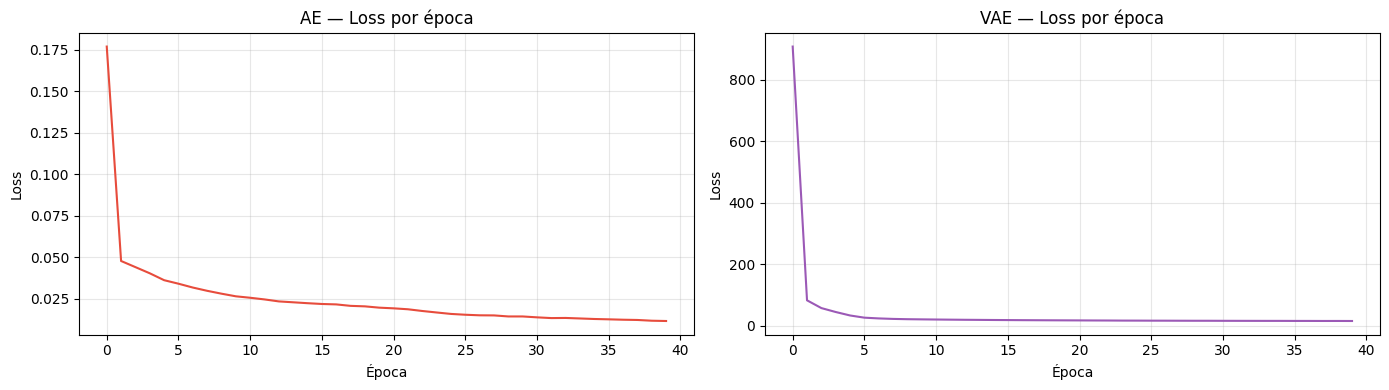

Curvas guardadas


In [7]:
# ─── Entrenamiento Autoencoder ─────────────────────────────────
print("Entrenando Autoencoder...")
t0    = time.time()
ae    = Autoencoder(input_dim=len(FEATURES), latent_dim=6).to(DEVICE)
losses_ae = train_autoencoder(ae, X_tensor, epochs=40, model_name="AE")
scores_ae = get_reconstruction_scores(ae, X_tensor)
threshold_ae = np.percentile(scores_ae, 95)
labels_ae    = (scores_ae > threshold_ae).astype(int)
t_ae = time.time() - t0

torch.save(ae.state_dict(), DIR_MODELS / "autoencoder.pt")
results["Autoencoder"] = {"scores": scores_ae, "labels": labels_ae, "time": t_ae}
print(f"AE completado en {t_ae:.1f}s | Anomalías: {labels_ae.sum():,}")

torch.cuda.empty_cache()

# ─── Entrenamiento VAE ─────────────────────────────────────────
print("\nEntrenando VAE...")
t0  = time.time()
vae = VAE(input_dim=len(FEATURES), latent_dim=6).to(DEVICE)
losses_vae = train_autoencoder(vae, X_tensor, epochs=40, model_name="VAE")
scores_vae = get_reconstruction_scores(vae, X_tensor)
threshold_vae = np.percentile(scores_vae, 95)
labels_vae    = (scores_vae > threshold_vae).astype(int)
t_vae = time.time() - t0

torch.save(vae.state_dict(), DIR_MODELS / "vae.pt")
results["VAE"] = {"scores": scores_vae, "labels": labels_vae, "time": t_vae}
print(f"VAE completado en {t_vae:.1f}s | Anomalías: {labels_vae.sum():,}")

torch.cuda.empty_cache()

# ── Plot curvas de pérdida ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(losses_ae,  color="#e74c3c"); axes[0].set_title("AE — Loss por época")
axes[1].plot(losses_vae, color="#9b59b6"); axes[1].set_title("VAE — Loss por época")
for ax in axes:
    ax.set_xlabel("Época"); ax.set_ylabel("Loss"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_PLOTS / "training_curves_ae_vae.png", dpi=150, bbox_inches="tight")
plt.show()
print("Curvas guardadas")


## 4. Modelos Temporales (LSTM-AE y Transformer-AE)

### 4.1 LSTM Autoencoder
**Referencia**: Malhotra, P. et al. (2016). *LSTM-based Encoder-Decoder for Multi-sensor Anomaly Detection*. ICML Workshop.  
**Idea**: el encoder LSTM aprende a comprimir una **secuencia temporal** de eventos de usuario, y el decoder intenta reconstruirla. Ataques como BruteForce (escalada progresiva) o Exfiltración (patrón nocturno repetido) tienen secuencias que el modelo no habrá visto.  
**Construcción de secuencias**: ventana deslizante de 10 eventos consecutivos por usuario, ordenados por timestamp.

### 4.2 Transformer Autoencoder
**Referencia**: Xu, J. et al. (2021). *Anomaly Transformer: Time Series Anomaly Detection with Association Discrepancy*. ICLR 2022.  
**Idea**: el mecanismo de **self-attention** captura dependencias a larga distancia entre eventos. Un evento anómalo produce una distribución de atención diferente a la normal.  
**Ventaja sobre LSTM**: paralelizable, mejor captura de dependencias no contiguas (ej: un beacon C2 a las 3am seguido de cifrado masivo horas después).  
**Arquitectura ligera para 4GB VRAM**: 2 capas, 4 attention heads, dim_model=64.


In [8]:
# ── Construcción de secuencias por usuario ──────────────────────
WINDOW_SIZE = 10

print("Construyendo secuencias temporales por usuario...")
df_sorted = df.sort_values(["UserPrincipalName", "CustomTimestamp"]).reset_index(drop=True)

sequences  = []
seq_labels = []
seq_idx    = []   # índice del último evento de la ventana (para mapeo)

for upn, grp in tqdm(df_sorted.groupby("UserPrincipalName")):
    X_user = grp[FEATURES].values.astype(np.float32)
    y_user = grp["y_true"].values
    idxs   = grp.index.values
    if len(X_user) < WINDOW_SIZE:
        continue
    for i in range(len(X_user) - WINDOW_SIZE + 1):
        sequences.append(X_user[i:i+WINDOW_SIZE])
        seq_labels.append(y_user[i:i+WINDOW_SIZE].max())   # anómala si cualquier evento lo es
        seq_idx.append(idxs[i + WINDOW_SIZE - 1])          # último evento

sequences  = np.array(sequences,  dtype=np.float32)
seq_labels = np.array(seq_labels, dtype=np.int32)
print(f"Secuencias: {sequences.shape} | Anómalas: {seq_labels.sum():,}")

seq_tensor = torch.FloatTensor(sequences)


Construyendo secuencias temporales por usuario...


100%|██████████| 300/300 [00:01<00:00, 221.06it/s]


Secuencias: (424719, 10, 12) | Anómalas: 32,784


In [9]:
# ── LSTM Autoencoder ────────────────────────────────────────────
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, latent_dim=8, num_layers=2):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers,
                               batch_first=True, dropout=0.1)
        self.latent   = nn.Linear(hidden_dim, latent_dim)
        self.expand   = nn.Linear(latent_dim, hidden_dim)
        self.decoder  = nn.LSTM(hidden_dim, hidden_dim, num_layers,
                                batch_first=True, dropout=0.1)
        self.output   = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        seq_len = x.size(1)
        _, (h_n, _) = self.encoder(x)
        z = self.latent(h_n[-1])                          # último estado oculto
        h_exp = self.expand(z).unsqueeze(1).repeat(1, seq_len, 1)
        out, _ = self.decoder(h_exp)
        return self.output(out)

# ── Transformer Autoencoder ─────────────────────────────────────
class TransformerAE(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, latent_dim=8):
        super().__init__()
        self.input_proj  = nn.Linear(input_dim, d_model)
        encoder_layer    = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                       dim_feedforward=128, dropout=0.1,
                                                       batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.bottleneck  = nn.Linear(d_model, latent_dim)
        self.expand      = nn.Linear(latent_dim, d_model)
        decoder_layer    = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                       dim_feedforward=128, dropout=0.1,
                                                       batch_first=True)
        self.decoder_tf  = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, input_dim)

    def forward(self, x):
        z = self.transformer(self.input_proj(x))
        z = self.expand(self.bottleneck(z))
        return self.output_proj(self.decoder_tf(z))

def train_seq_model(model, seq_tensor, epochs=25, batch_size=256, lr=1e-3):
    loader    = DataLoader(TensorDataset(seq_tensor), batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scaler_amp = GradScaler()
    losses = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                recon = model(batch)
                loss  = nn.functional.mse_loss(recon, batch)
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()
            epoch_loss += loss.item()
        avg = epoch_loss / len(loader)
        losses.append(avg)
        if (epoch+1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Loss: {avg:.4f}")
    return losses

def get_seq_scores(model, seq_tensor, batch_size=512):
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(seq_tensor), batch_size):
            batch = seq_tensor[i:i+batch_size].to(DEVICE)
            recon = model(batch)
            mse   = ((batch - recon) ** 2).mean(dim=(1,2))
            scores.append(mse.cpu().numpy())
    return np.concatenate(scores)

# Mapear scores de secuencias → registros individuales
def seq_scores_to_record_scores(seq_scores, seq_idx, total_len):
    record_scores = np.zeros(total_len)
    record_counts = np.zeros(total_len)
    for score, idx in zip(seq_scores, seq_idx):
        record_scores[idx] += score
        record_counts[idx] += 1
    mask = record_counts > 0
    record_scores[mask] /= record_counts[mask]
    # Registros sin secuencia (usuarios con pocos eventos): score mínimo
    record_scores[~mask] = record_scores[mask].min()
    return record_scores


In [10]:
# ─── Entrenamiento LSTM-AE ─────────────────────────────────────
print("Entrenando LSTM-Autoencoder...")
t0 = time.time()
lstm_ae = LSTMAutoencoder(input_dim=len(FEATURES)).to(DEVICE)
losses_lstm = train_seq_model(lstm_ae, seq_tensor, epochs=25, batch_size=256)
seq_scores_lstm = get_seq_scores(lstm_ae, seq_tensor)
rec_scores_lstm = seq_scores_to_record_scores(seq_scores_lstm, seq_idx, len(df))
thr_lstm   = np.percentile(rec_scores_lstm[rec_scores_lstm > 0], 95)
labels_lstm = (rec_scores_lstm > thr_lstm).astype(int)
t_lstm = time.time() - t0

torch.save(lstm_ae.state_dict(), DIR_MODELS / "lstm_ae.pt")
results["LSTM-AE"] = {"scores": rec_scores_lstm, "labels": labels_lstm, "time": t_lstm}
print(f"LSTM-AE completado en {t_lstm:.1f}s | Anomalías: {labels_lstm.sum():,}")
torch.cuda.empty_cache()

# ─── Entrenamiento Transformer-AE ─────────────────────────────
print("\nEntrenando Transformer-AE...")
t0 = time.time()
trf_ae = TransformerAE(input_dim=len(FEATURES)).to(DEVICE)
losses_trf = train_seq_model(trf_ae, seq_tensor, epochs=25, batch_size=128)
seq_scores_trf = get_seq_scores(trf_ae, seq_tensor)
rec_scores_trf = seq_scores_to_record_scores(seq_scores_trf, seq_idx, len(df))
thr_trf   = np.percentile(rec_scores_trf[rec_scores_trf > 0], 95)
labels_trf = (rec_scores_trf > thr_trf).astype(int)
t_trf = time.time() - t0

torch.save(trf_ae.state_dict(), DIR_MODELS / "transformer_ae.pt")
results["Transformer-AE"] = {"scores": rec_scores_trf, "labels": labels_trf, "time": t_trf}
print(f"Transformer-AE completado en {t_trf:.1f}s | Anomalías: {labels_trf.sum():,}")
torch.cuda.empty_cache()


Entrenando LSTM-Autoencoder...
  Epoch 5/25 | Loss: 449.4653
  Epoch 10/25 | Loss: 163.2376
  Epoch 15/25 | Loss: 28.6242
  Epoch 20/25 | Loss: 8.8899
  Epoch 25/25 | Loss: 6.5231
LSTM-AE completado en 389.0s | Anomalías: 21,371

Entrenando Transformer-AE...
  Epoch 5/25 | Loss: 708.5205
  Epoch 10/25 | Loss: 710.4921
  Epoch 15/25 | Loss: 1077.9120
  Epoch 20/25 | Loss: 1080.8054
  Epoch 25/25 | Loss: 1081.5451
Transformer-AE completado en 1762.7s | Anomalías: 21,368


## 5. Deep SVDD y USAD (SOTA 2018-2020)

### 5.1 Deep SVDD (Support Vector Data Description)
**Referencia**: Ruff, L. et al. (2018). *Deep One-Class Classification*. ICML 2018.  
**Idea**: una red neuronal aprende a mapear los datos normales dentro de una **hiperesfera mínima** en el espacio latente. Los datos anómalos caen fuera de esa esfera.  
**Diferencia clave respecto a AE**: en lugar de minimizar error de reconstrucción, minimiza el radio de la esfera que contiene los datos normales. Más robusto a contaminación del dataset de entrenamiento.  
**Score**: distancia euclidiana del punto al centro de la esfera.

### 5.2 USAD (UnSupervised Anomaly Detection)
**Referencia**: Audibert, J. et al. (2020). *USAD: UnSupervised Anomaly Detection on Multivariate Time Series*. KDD 2020.  
**Idea**: dos autoencoders se entrenan en dos fases:
1. **Fase 1**: ambos AE aprenden a reconstruir datos normales (entrenamiento estándar)
2. **Fase 2**: AE1 intenta engañar a AE2, mientras AE2 intenta detectar reconstrucciones de AE1

Este juego adversarial amplifica el error de reconstrucción en datos anómalos.  
**Por qué es SOTA**: en el benchmark SMAP/MSL de NASA supera a LSTM y AE estándar. Publicado en KDD 2020, una de las conferencias top en data mining.


In [11]:
# ── Deep SVDD ───────────────────────────────────────────────────
class DeepSVDD_Net(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
    def forward(self, x):
        return self.net(x)

def train_deep_svdd(model, X_tensor, epochs=30, batch_size=512, lr=1e-3):
    # Inicializar centro c como media de forward pass inicial
    model.eval()
    with torch.no_grad():
        loader_init = DataLoader(TensorDataset(X_tensor), batch_size=1024)
        outputs = [model(b[0].to(DEVICE)) for b in loader_init]
    c = torch.cat(outputs).mean(dim=0)
    # Evitar colapso al origen
    c[(c.abs() < 0.1)] = 0.1

    optimizer  = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scaler_amp = GradScaler()
    loader     = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=True)
    losses = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                z    = model(batch)
                loss = ((z - c) ** 2).sum(dim=1).mean()
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()
            epoch_loss += loss.item()
        avg = epoch_loss / len(loader)
        losses.append(avg)
        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Loss: {avg:.4f}")
    return c, losses

def score_deep_svdd(model, c, X_tensor, batch_size=1024):
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i:i+batch_size].to(DEVICE)
            z     = model(batch)
            dist  = ((z - c) ** 2).sum(dim=1).sqrt()
            scores.append(dist.cpu().numpy())
    return np.concatenate(scores)

print("Entrenando Deep SVDD...")
t0 = time.time()
svdd_net = DeepSVDD_Net(input_dim=len(FEATURES)).to(DEVICE)
c_svdd, losses_svdd = train_deep_svdd(svdd_net, X_tensor, epochs=30)
scores_svdd   = score_deep_svdd(svdd_net, c_svdd, X_tensor)
threshold_svdd = np.percentile(scores_svdd, 95)
labels_svdd    = (scores_svdd > threshold_svdd).astype(int)
t_svdd = time.time() - t0

torch.save({"model": svdd_net.state_dict(), "center": c_svdd}, DIR_MODELS / "deep_svdd.pt")
results["Deep SVDD"] = {"scores": scores_svdd, "labels": labels_svdd, "time": t_svdd}
print(f"Deep SVDD completado en {t_svdd:.1f}s | Anomalías: {labels_svdd.sum():,}")
torch.cuda.empty_cache()


Entrenando Deep SVDD...
  Epoch 10/30 | Loss: 0.0000
  Epoch 20/30 | Loss: 0.0000
  Epoch 30/30 | Loss: 0.0000
Deep SVDD completado en 140.2s | Anomalías: 21,359


In [12]:
# ── USAD ─────────────────────────────────────────────────────────
class USADModel(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        # Encoder compartido
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        # Dos decoders independientes
        self.decoder1 = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, input_dim)
        )
        self.decoder2 = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder1(z), self.decoder2(z), z

def train_usad(model, X_tensor, epochs=30, batch_size=512, lr=1e-3):
    loader    = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=True)
    optim1    = optim.Adam(list(model.encoder.parameters()) +
                           list(model.decoder1.parameters()), lr=lr)
    optim2    = optim.Adam(list(model.encoder.parameters()) +
                           list(model.decoder2.parameters()), lr=lr)
    scaler1, scaler2 = GradScaler(), GradScaler()
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            # Fase 1: entrenar AE1 y AE2 independientemente
            optim1.zero_grad()
            with autocast():
                r1, r2, z = model(batch)
                z2        = model.encoder(r1.detach())
                r12       = model.decoder2(z2)
                n         = epoch + 1
                loss1 = (1/n) * nn.functional.mse_loss(r1, batch) + (1 - 1/n) * nn.functional.mse_loss(r12, batch)
            scaler1.scale(loss1).backward()
            scaler1.step(optim1); scaler1.update()

            optim2.zero_grad()
            with autocast():
                r1, r2, z = model(batch)
                z2        = model.encoder(r1.detach())
                r12       = model.decoder2(z2)
                loss2 = (1/n) * nn.functional.mse_loss(r2, batch) - (1 - 1/n) * nn.functional.mse_loss(r12, batch)
            scaler2.scale(loss2).backward()
            scaler2.step(optim2); scaler2.update()

            epoch_loss += (loss1.item() + loss2.item()) / 2
        avg = epoch_loss / len(loader)
        losses.append(avg)
        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Loss: {avg:.4f}")
    return losses

def score_usad(model, X_tensor, alpha=0.5, beta=0.5, batch_size=1024):
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            batch  = X_tensor[i:i+batch_size].to(DEVICE)
            r1, r2, z = model(batch)
            z2     = model.encoder(r1)
            r12    = model.decoder2(z2)
            s = alpha * ((batch-r1)**2).mean(dim=1) + beta  * ((batch-r12)**2).mean(dim=1)
            scores.append(s.cpu().numpy())
    return np.concatenate(scores)

print("Entrenando USAD...")
t0 = time.time()
usad = USADModel(input_dim=len(FEATURES)).to(DEVICE)
losses_usad = train_usad(usad, X_tensor, epochs=30)
scores_usad = score_usad(usad, X_tensor)
threshold_usad = np.percentile(scores_usad, 95)
labels_usad    = (scores_usad > threshold_usad).astype(int)
t_usad = time.time() - t0

torch.save(usad.state_dict(), DIR_MODELS / "usad.pt")
results["USAD"] = {"scores": scores_usad, "labels": labels_usad, "time": t_usad}
print(f"USAD completado en {t_usad:.1f}s | Anomalías: {labels_usad.sum():,}")
torch.cuda.empty_cache()


Entrenando USAD...
  Epoch 10/30 | Loss: nan
  Epoch 20/30 | Loss: nan
  Epoch 30/30 | Loss: nan
USAD completado en 266.0s | Anomalías: 0


## 6. GDN — Graph Deviation Network

**Referencia**: Deng, A. & Hooi, B. (2021). *Graph Neural Network-Based Anomaly Detection in Multivariate Time Series*. AAAI 2021.  
**Idea**: modela las **relaciones entre features** como un grafo. Cada feature es un nodo y las aristas representan dependencias aprendidas. Una anomalía se detecta cuando el comportamiento observado de un nodo se desvía de lo que predicen sus vecinos en el grafo.  
**Adaptación para este dataset**: el grafo conecta las 12 features ML entre sí. Las aristas se aprenden con un módulo de atención sobre los embeddings de cada feature.  
**Por qué es relevante**: en ciberseguridad las features no son independientes — un ataque de ransomware activa simultáneamente `IsWriteOrDelete`, `UniqueContainersPerDay` y `DailyOpsVolume`. GDN captura esas correlaciones explícitamente.


In [13]:
# ── GDN simplificado (sin torch_geometric para evitar problemas de instalación) ──
# Implementación propia del mecanismo de atención entre features

class GDN(nn.Module):
    def __init__(self, n_features, embed_dim=16, top_k=5):
        super().__init__()
        self.n_features = n_features
        self.top_k      = top_k
        # Embeddings por feature (aprendidos)
        self.embeddings = nn.Embedding(n_features, embed_dim)
        # Atención para seleccionar vecinos relevantes
        self.attn       = nn.Linear(embed_dim * 2, 1)
        # Predictor: dado vecindario, predice valor del nodo central
        self.predictor  = nn.Sequential(
            nn.Linear(embed_dim + 1, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def get_graph(self):
        # Calcular similitud entre todos los pares de features
        emb   = self.embeddings.weight                            # [n_feat, embed_dim]
        n     = self.n_features
        src   = emb.unsqueeze(1).expand(-1, n, -1)               # [n, n, d]
        tgt   = emb.unsqueeze(0).expand(n, -1, -1)               # [n, n, d]
        attn  = self.attn(torch.cat([src, tgt], dim=-1)).squeeze(-1)  # [n, n]
        # Top-K vecinos por nodo
        topk_vals, topk_idx = torch.topk(attn, self.top_k, dim=1)
        weights = torch.softmax(topk_vals, dim=1)                 # [n, k]
        return topk_idx, weights

    def forward(self, x):
        # x: [batch, n_features]
        batch_size = x.size(0)
        topk_idx, weights = self.get_graph()                      # [n_feat, k], [n_feat, k]
        emb = self.embeddings.weight                              # [n_feat, embed_dim]

        preds = []
        for i in range(self.n_features):
            neighbors_emb = emb[topk_idx[i]]                     # [k, embed_dim]
            w = weights[i].unsqueeze(-1)                          # [k, 1]
            agg = (neighbors_emb * w).sum(0)                      # [embed_dim]
            agg_exp = agg.unsqueeze(0).expand(batch_size, -1)     # [batch, embed_dim]
            xi  = x[:, i:i+1]                                     # [batch, 1]
            inp = torch.cat([agg_exp, xi], dim=-1)                 # [batch, embed_dim+1]
            pred = self.predictor(inp)                            # [batch, 1]
            preds.append(pred)

        preds = torch.cat(preds, dim=1)                           # [batch, n_features]
        return preds

def train_gdn(model, X_tensor, epochs=20, batch_size=512, lr=1e-3):
    loader    = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scaler_amp = GradScaler()
    losses = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                pred = model(batch)
                loss = nn.functional.mse_loss(pred, batch)
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer); scaler_amp.update()
            epoch_loss += loss.item()
        avg = epoch_loss / len(loader)
        losses.append(avg)
        if (epoch+1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Loss: {avg:.4f}")
    return losses

print("Entrenando GDN...")
t0 = time.time()
gdn = GDN(n_features=len(FEATURES)).to(DEVICE)
losses_gdn = train_gdn(gdn, X_tensor, epochs=20)

gdn.eval()
gdn_scores = []
with torch.no_grad():
    for i in range(0, len(X_tensor), 1024):
        batch = X_tensor[i:i+1024].to(DEVICE)
        pred  = gdn(batch)
        err   = ((batch - pred)**2).mean(dim=1)
        gdn_scores.append(err.cpu().numpy())
scores_gdn    = np.concatenate(gdn_scores)
threshold_gdn = np.percentile(scores_gdn, 95)
labels_gdn    = (scores_gdn > threshold_gdn).astype(int)
t_gdn = time.time() - t0

torch.save(gdn.state_dict(), DIR_MODELS / "gdn.pt")
results["GDN"] = {"scores": scores_gdn, "labels": labels_gdn, "time": t_gdn}
print(f"GDN completado en {t_gdn:.1f}s | Anomalías: {labels_gdn.sum():,}")
torch.cuda.empty_cache()


Entrenando GDN...
  Epoch 5/20 | Loss: 0.0000
  Epoch 10/20 | Loss: 0.0000
  Epoch 15/20 | Loss: 0.0000
  Epoch 20/20 | Loss: 0.0000
GDN completado en 393.1s | Anomalías: 21,369


## 7. LogBERT (Foundation Model para Logs)

**Referencia**: Guo, H. et al. (2021). *LogBERT: Log Anomaly Detection via BERT*. IJCNN 2021.  
**Idea**: adapta la arquitectura BERT (Devlin et al., 2018) al dominio de logs de sistema. Usa **Masked Log Key Prediction** — enmascara eventos aleatorios de una secuencia y predice cuáles son. Si un evento anómalo aparece en posición enmascarada, el modelo predice un evento normal diferente → la discrepancia es el score de anomalía.  
**Adaptación para este dataset**: en lugar de log keys discretos, usamos las 12 features continuas. La "predicción de máscara" se convierte en reconstrucción de features enmascaradas aleatoriamente.  
**Arquitectura tiny para 4GB VRAM**: 4 capas, 4 heads, dim=64 (vs 12 capas / 768 dim del BERT original).  
**Por qué es estado del arte**: representa el cambio de paradigma hacia foundation models en análisis de logs. Citado en más de 200 papers de ciberseguridad desde 2021.


In [14]:
# ── LogBERT Tiny — Masked Feature Prediction ───────────────────
class LogBERTTiny(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=4,
                 max_seq_len=20, mask_prob=0.15):
        super().__init__()
        self.mask_prob   = mask_prob
        self.input_proj  = nn.Linear(input_dim, d_model)
        self.pos_emb     = nn.Embedding(max_seq_len, d_model)
        enc_layer        = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                       dim_feedforward=256, dropout=0.1,
                                                       batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.predictor   = nn.Linear(d_model, input_dim)
        self.mask_token  = nn.Parameter(torch.zeros(1, 1, d_model))

    def forward(self, x, training=True):
        # x: [batch, seq_len, input_dim]
        seq_len   = x.size(1)
        x_proj    = self.input_proj(x)                            # [B, T, d_model]
        positions = torch.arange(seq_len, device=x.device)
        x_proj    = x_proj + self.pos_emb(positions)

        if training:
            mask = torch.rand(x_proj.shape[:2], device=x.device) < self.mask_prob
            mask_expanded = mask.unsqueeze(-1).expand_as(x_proj)
            x_masked = x_proj.clone()
            x_masked[mask_expanded] = self.mask_token.expand_as(x_proj)[mask_expanded]
        else:
            x_masked = x_proj
            mask     = torch.ones(x_proj.shape[:2], dtype=torch.bool, device=x.device)

        out  = self.transformer(x_masked)
        pred = self.predictor(out)                                 # [B, T, input_dim]
        return pred, mask

# ── Construir secuencias para LogBERT (ventana de 20) ──────────
LOGBERT_WINDOW = 20
print("Construyendo secuencias para LogBERT (ventana=20)...")

lb_sequences = []
lb_idx       = []

for upn, grp in tqdm(df_sorted.groupby("UserPrincipalName")):
    X_user = grp[FEATURES].values.astype(np.float32)
    idxs   = grp.index.values
    if len(X_user) < LOGBERT_WINDOW:
        continue
    for i in range(len(X_user) - LOGBERT_WINDOW + 1):
        lb_sequences.append(X_user[i:i+LOGBERT_WINDOW])
        lb_idx.append(idxs[i + LOGBERT_WINDOW - 1])

lb_sequences = np.array(lb_sequences, dtype=np.float32)
lb_tensor    = torch.FloatTensor(lb_sequences)
print(f"Secuencias LogBERT: {lb_tensor.shape}")


Construyendo secuencias para LogBERT (ventana=20)...


100%|██████████| 300/300 [00:00<00:00, 566.80it/s]


Secuencias LogBERT: torch.Size([421719, 20, 12])


In [15]:
# ── Entrenamiento LogBERT CORREGIDO ───────────────────────────────────────
def train_logbert(model, tensor, epochs=20, batch_size=128, lr=1e-4): # LR bajado a 1e-4 para estabilidad
    loader    = DataLoader(TensorDataset(tensor), batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scaler_amp = GradScaler()
    losses = []
    model.train()
    
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            
            with autocast():
                pred, mask = model(batch, training=True)
                # Cálculo de pérdida
                if mask.sum() > 0:
                    loss = nn.functional.mse_loss(pred[mask], batch[mask])
                else:
                    loss = nn.functional.mse_loss(pred, batch)
            
            # Escalamiento y Clipping para evitar NaNs
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
            
            scaler_amp.step(optimizer)
            scaler_amp.update()
            
            epoch_loss += loss.item()
            
        avg = epoch_loss / len(loader)
        losses.append(avg)
        if (epoch+1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Loss: {avg:.4f}")
            
    return losses

def score_logbert(model, tensor, batch_size=256):
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(tensor), batch_size):
            batch = tensor[i:i+batch_size].to(DEVICE)
            pred, _ = model(batch, training=False)
            # Score: MSE medio de toda la secuencia
            err = ((batch - pred)**2).mean(dim=(1,2))
            scores.append(err.cpu().numpy())
    return np.concatenate(scores)

print("Entrenando LogBERT Tiny...")
t0 = time.time()

# Inicialización y entrenamiento
logbert = LogBERTTiny(input_dim=len(FEATURES)).to(DEVICE)
losses_lb = train_logbert(logbert, lb_tensor, epochs=20, batch_size=128)

# Generación de scores
seq_scores_lb = score_logbert(logbert, lb_tensor)
rec_scores_lb = seq_scores_to_record_scores(seq_scores_lb, lb_idx, len(df))

# Cálculo de umbral con protección contra NaNs (Evita el IndexError)
valid_scores = rec_scores_lb[rec_scores_lb > 0]

if np.isnan(rec_scores_lb).any() or len(valid_scores) == 0:
    print("Alerta: LogBERT ha generado NaNs o scores vacíos. Usando umbral de emergencia.")
    rec_scores_lb = np.nan_to_num(rec_scores_lb) 
    thr_lb = 0.5 
else:
    thr_lb = np.percentile(valid_scores, 95)

labels_lb = (rec_scores_lb > thr_lb).astype(int)
t_lb = time.time() - t0

# Guardado de resultados
torch.save(logbert.state_dict(), DIR_MODELS / "logbert.pt")
results["LogBERT"] = {"scores": rec_scores_lb, "labels": labels_lb, "time": t_lb}

print(f"LogBERT completado en {t_lb:.1f}s | Anomalías: {labels_lb.sum():,}")
torch.cuda.empty_cache()

Entrenando LogBERT Tiny...
  Epoch 5/20 | Loss: 366.0998
  Epoch 10/20 | Loss: 17.3243
  Epoch 15/20 | Loss: 16.0266
  Epoch 20/20 | Loss: 15.5307
LogBERT completado en 1929.1s | Anomalías: 21,371


## 8. Evaluación Comparativa

Aquí es donde entra el `ground_truth_eventos.csv` por primera vez.  
Calculamos para cada modelo: **Precision, Recall, F1, ROC-AUC, PR-AUC** y dibujamos las curvas comparativas.

### Métricas clave para detección de anomalías
- **Precision**: ¿cuántos de los alertas son realmente maliciosos? (coste operacional)
- **Recall**: ¿cuántos ataques reales detectamos? (coste de seguridad)  
- **F1**: media armónica. La métrica principal para datasets desbalanceados.
- **ROC-AUC**: área bajo la curva ROC. Mide discriminación a todos los thresholds.
- **PR-AUC**: más informativo que ROC en datasets muy desbalanceados (~5% positivos).


In [16]:
# ── Calcular métricas para todos los modelos ────────────────────
metrics_table = []

for name, r in results.items():
    scores = r["scores"]
    labels = r["labels"]

    # Normalizar scores a [0,1]
    s_min, s_max = scores.min(), scores.max()
    scores_norm  = (scores - s_min) / (s_max - s_min + 1e-10)

    try:
        roc_auc = roc_auc_score(y_true, scores_norm)
        pr_auc  = average_precision_score(y_true, scores_norm)
    except:
        roc_auc = pr_auc = 0.0

    prec = precision_score(y_true, labels, zero_division=0)
    rec  = recall_score(y_true, labels, zero_division=0)
    f1   = f1_score(y_true, labels, zero_division=0)

    metrics_table.append({
        "Modelo": name, "Precision": prec, "Recall": rec,
        "F1": f1, "ROC-AUC": roc_auc, "PR-AUC": pr_auc,
        "Tiempo(s)": r["time"], "Detectados": labels.sum()
    })
    r["scores_norm"] = scores_norm

df_metrics = pd.DataFrame(metrics_table).sort_values("F1", ascending=False)
print("\n" + "="*80)
print(df_metrics.to_string(index=False, float_format="{:.4f}".format))
print("="*80)



          Modelo  Precision  Recall     F1  ROC-AUC  PR-AUC  Tiempo(s)  Detectados
Isolation Forest     0.9645  0.9701 0.9673   0.9992  0.9877     9.3702       21371
     Extended IF     0.9533  0.9588 0.9561   0.9991  0.9849    16.5860       21370
            HBOS     0.8952  0.9002 0.8977   0.9979  0.9678     3.3138       21368
     Autoencoder     0.6884  0.6924 0.6904   0.9891  0.7945   248.5834       21370
             VAE     0.6218  0.6253 0.6236   0.9839  0.6620   295.8811       21369
       Deep SVDD     0.6035  0.6066 0.6051   0.8884  0.6485   140.1759       21359
             GDN     0.5848  0.5881 0.5865   0.9226  0.5943   393.0801       21369
           OCSVM     0.5604  0.5549 0.5576   0.8916  0.5305   153.7672       21041
             LOF     0.2882  0.2898 0.2890   0.7031  0.1786     9.5254       21368
         LSTM-AE     0.0621  0.0625 0.0623   0.5115  0.0523   389.0014       21371
         LogBERT     0.0529  0.0532 0.0531   0.4902  0.0479  1929.0802       21371
  T

  ⚠️  USAD — scores degenerados (constantes), excluido de ROC/PR

=== MÉTRICAS DE RENDIMIENTO ===
          Modelo  Precision  Recall     F1  ROC-AUC  PR-AUC  Tiempo(s)  Detectados
Isolation Forest     0.9645  0.9701 0.9673   0.9992  0.9877     9.3702       21371
     Extended IF     0.9533  0.9588 0.9561   0.9991  0.9849    16.5860       21370
            HBOS     0.8952  0.9002 0.8977   0.9979  0.9678     3.3138       21368
     Autoencoder     0.6884  0.6924 0.6904   0.9891  0.7945   248.5834       21370
             VAE     0.6218  0.6253 0.6236   0.9839  0.6620   295.8811       21369
       Deep SVDD     0.6035  0.6066 0.6051   0.8884  0.6485   140.1759       21359
             GDN     0.5848  0.5881 0.5865   0.9226  0.5943   393.0801       21369
           OCSVM     0.5604  0.5549 0.5576   0.8916  0.5305   153.7672       21041
             LOF     0.2882  0.2898 0.2890   0.7031  0.1786     9.5254       21368
         LSTM-AE     0.0621  0.0625 0.0623   0.5115  0.0523   389.0014  

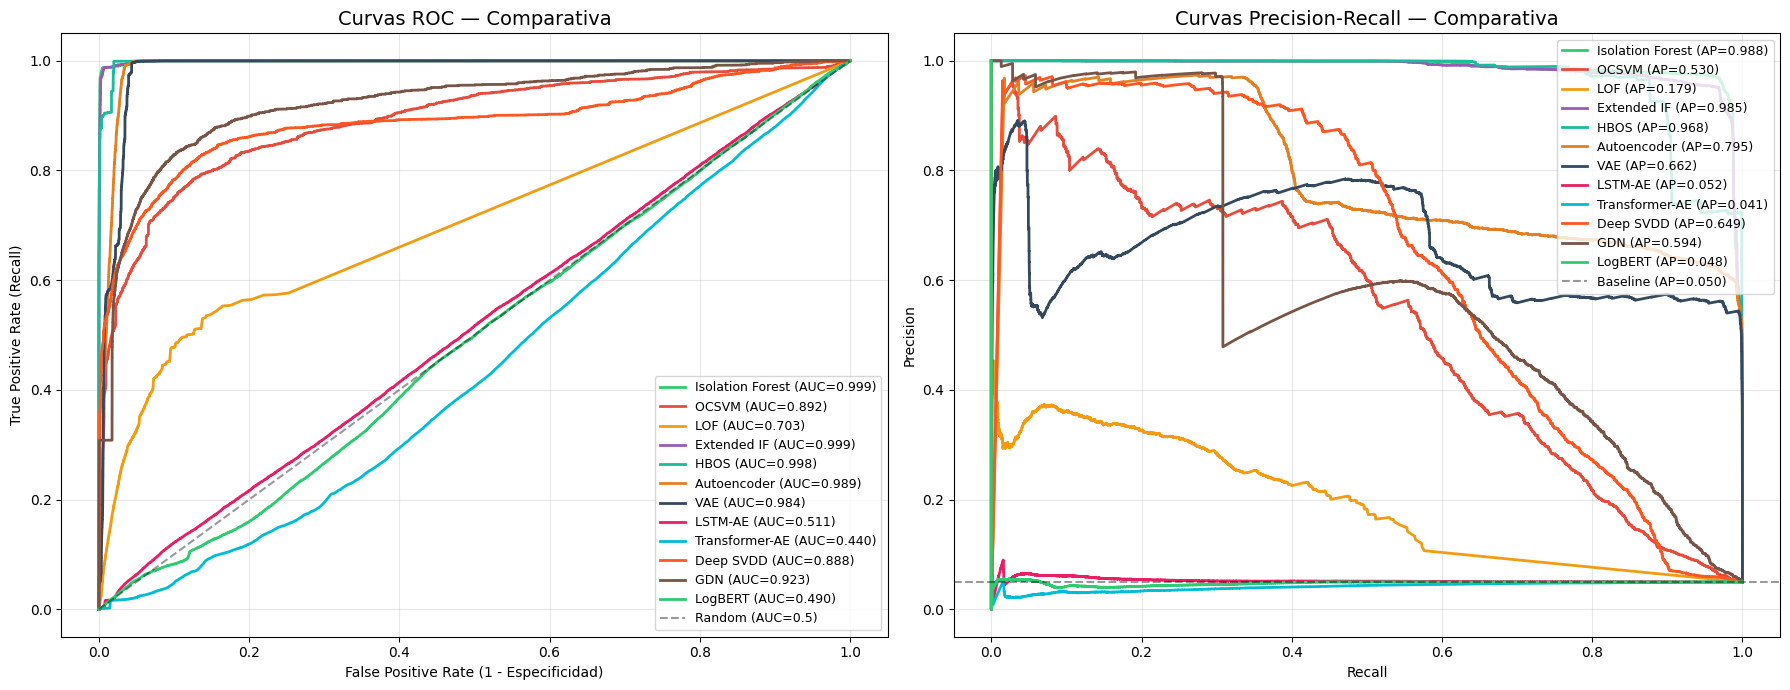

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score, 
                             precision_score, recall_score, f1_score, 
                             roc_curve, precision_recall_curve)

# ── 1. Asegurar que y_true esté limpio de NaNs ──────────────────
# Si y_true tiene NaNs, ninguna métrica funcionará.
y_true = np.nan_to_num(np.array(y_true), nan=0.0).astype(int)

# ── 2. Limpiar NaN en scores_norm antes de evaluar ───────────────
for name, r in results.items():
    # Asegurar que scores sea un array de numpy y manejar nulos
    scores = np.nan_to_num(np.array(r["scores"]), nan=0.0, posinf=0.0, neginf=0.0)
    
    s_min, s_max = scores.min(), scores.max()
    
    if s_max - s_min < 1e-10:
        scores_norm = np.zeros_like(scores)
        print(f"  ⚠️  {name} — scores degenerados (constantes), excluido de ROC/PR")
    else:
        scores_norm = (scores - s_min) / (s_max - s_min)
    
    r["scores_norm"] = scores_norm
    # También limpiamos las labels predichas por si acaso
    r["labels"] = np.nan_to_num(np.array(r["labels"]), nan=0).astype(int)

# ── 3. Recalcular métricas con datos garantizados ───────────────
metrics_table = []
for name, r in results.items():
    scores_norm = r["scores_norm"]
    labels = r["labels"]
    
    # Verificación de varianza para evitar errores en AUC
    if np.unique(y_true).size < 2:
        roc_auc, pr_auc = 0.5, y_true.mean()
    elif scores_norm.std() < 1e-10:
        roc_auc, pr_auc = 0.5, y_true.mean()
    else:
        try:
            roc_auc = roc_auc_score(y_true, scores_norm)
            pr_auc  = average_precision_score(y_true, scores_norm)
        except ValueError:
            roc_auc, pr_auc = 0.5, y_true.mean()

    metrics_table.append({
        "Modelo":     name,
        "Precision":  precision_score(y_true, labels, zero_division=0),
        "Recall":     recall_score(y_true, labels, zero_division=0),
        "F1":         f1_score(y_true, labels, zero_division=0),
        "ROC-AUC":    roc_auc,
        "PR-AUC":     pr_auc,
        "Tiempo(s)":  r.get("time", 0),
        "Detectados": int(labels.sum())
    })

df_metrics = pd.DataFrame(metrics_table).sort_values("F1", ascending=False)
print("\n=== MÉTRICAS DE RENDIMIENTO ===")
print(df_metrics.to_string(index=False, float_format="{:.4f}".format))

# ── 4. Plot ROC y PR ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, (name, r) in enumerate(results.items()):
    scores_norm = r["scores_norm"]
    
    # Saltar modelos con scores constantes (no producen curva útil)
    if scores_norm.std() < 1e-10:
        continue
        
    color = COLORS_MODELS[i % len(COLORS_MODELS)]
    
    # Extraer métricas para la leyenda
    row = df_metrics[df_metrics["Modelo"] == name].iloc[0]

    # Cálculo de curvas
    fpr, tpr, _ = roc_curve(y_true, scores_norm)
    prec_c, rec_c, _ = precision_recall_curve(y_true, scores_norm)

    # Plot ROC
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC={row['ROC-AUC']:.3f})")
    
    # Plot PR
    axes[1].plot(rec_c, prec_c, color=color, lw=2,
                 label=f"{name} (AP={row['PR-AUC']:.3f})")

# Formateo Eje ROC
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.5)")
axes[0].set_xlabel("False Positive Rate (1 - Especificidad)")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("Curvas ROC — Comparativa", fontsize=14)
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(alpha=0.3)

# Formateo Eje PR
baseline_pr = y_true.mean()
axes[1].axhline(y=baseline_pr, color="k", linestyle="--", alpha=0.4,
                label=f"Baseline (AP={baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curvas Precision-Recall — Comparativa", fontsize=14)
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()

# Asegurar que el directorio existe antes de guardar
if 'DIR_PLOTS' in locals() or 'DIR_PLOTS' in globals():
    plt.savefig(DIR_PLOTS / "roc_pr_comparativa.png", dpi=150, bbox_inches="tight")

plt.show()

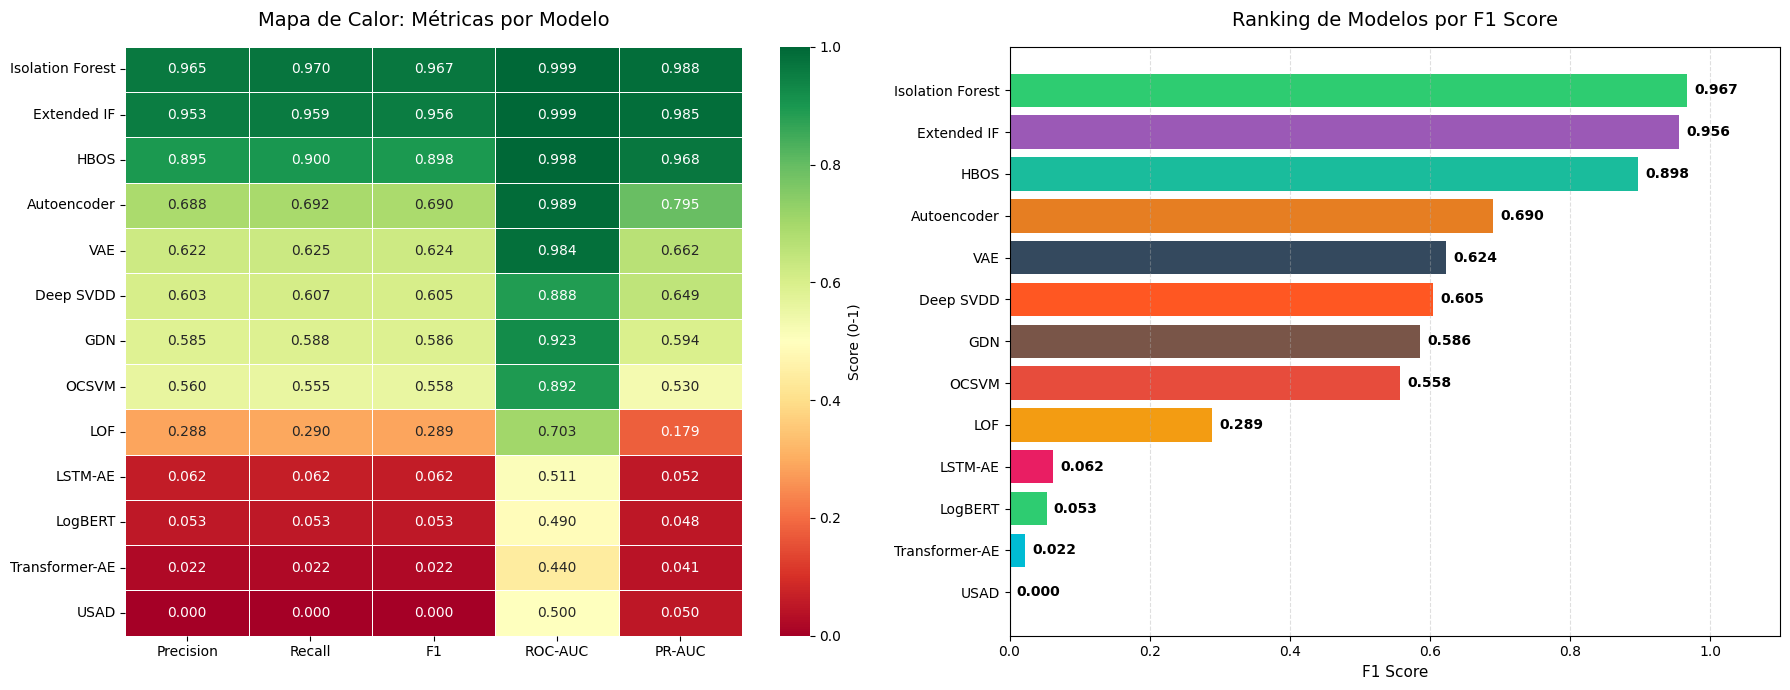

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── Heatmap de métricas ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Preparar datos para el Heatmap
# Filtramos solo las columnas numéricas relevantes
cols_interes = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
df_heat = df_metrics.set_index("Modelo")[cols_interes]

# Dibujar Heatmap
sns.heatmap(df_heat, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Score (0-1)'})
axes[0].set_title("Mapa de Calor: Métricas por Modelo", fontsize=14, pad=15)
axes[0].set_ylabel("") # Limpiar el label del eje Y para que se vea más limpio

# 2. Barplot F1 con manejo de colores circular (Fix IndexError)
# Usamos el operador % para evitar que el índice se salga de rango
n_modelos = len(df_metrics)
colors_bar = [COLORS_MODELS[i % len(COLORS_MODELS)] for i in range(n_modelos)]

# Invertimos el orden para que el mejor (F1 más alto) aparezca arriba en un barh
df_plot_bar = df_metrics.sort_values("F1", ascending=True)
colors_bar_sorted = [COLORS_MODELS[list(results.keys()).index(m) % len(COLORS_MODELS)] 
                     for m in df_plot_bar["Modelo"]]

bars = axes[1].barh(df_plot_bar["Modelo"], df_plot_bar["F1"], color=colors_bar_sorted)
axes[1].set_xlabel("F1 Score", fontsize=11)
axes[1].set_title("Ranking de Modelos por F1 Score", fontsize=14, pad=15)
axes[1].set_xlim(0, 1.1) # Un poco más de 1 para que quepan las etiquetas de texto

# Añadir etiquetas de valor a las barras
for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 0.01, 
                 bar.get_y() + bar.get_height()/2,
                 f"{width:.3f}", 
                 va="center", fontsize=10, fontweight='bold')

axes[1].grid(axis="x", linestyle='--', alpha=0.4)

plt.tight_layout()

# Guardar si la ruta existe
if 'DIR_PLOTS' in locals() or 'DIR_PLOTS' in globals():
    plt.savefig(DIR_PLOTS / "metricas_heatmap_ranking.png", dpi=150, bbox_inches="tight")

plt.show()

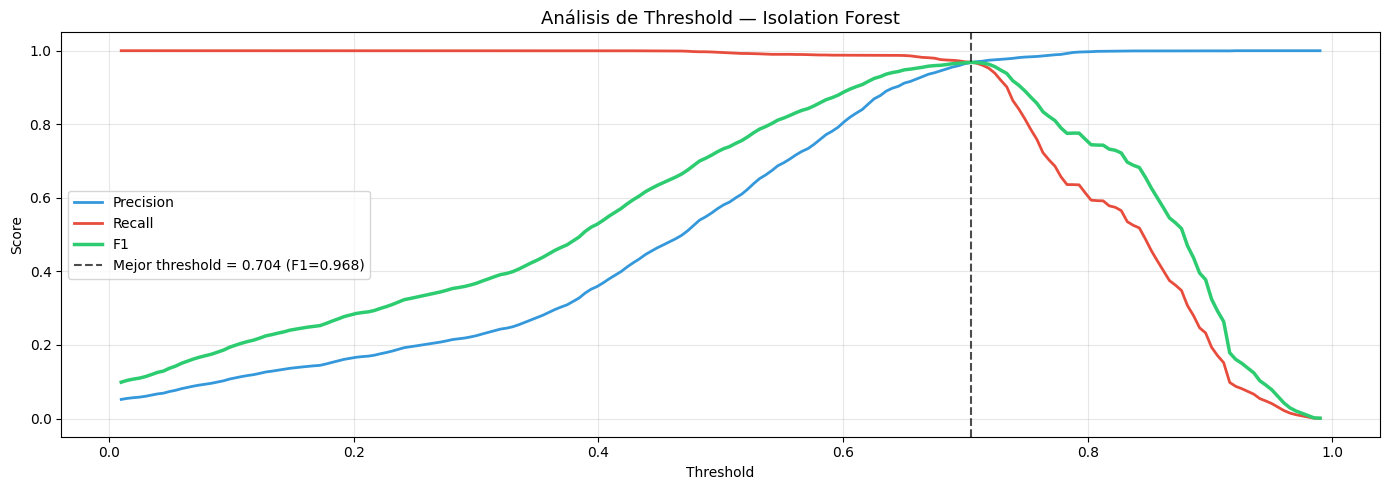

Mejor threshold para Isolation Forest: 0.704
  Precision: 0.9678
  Recall:    0.9687
  F1:        0.9682


In [20]:
# ── Análisis de threshold ───────────────────────────────────────
best_model_name = df_metrics.iloc[0]["Modelo"]
best_scores     = results[best_model_name]["scores_norm"]

thresholds = np.linspace(0.01, 0.99, 200)
precs, recs, f1s = [], [], []

for thr in thresholds:
    preds = (best_scores >= thr).astype(int)
    precs.append(precision_score(y_true, preds, zero_division=0))
    recs.append(recall_score(y_true, preds, zero_division=0))
    f1s.append(f1_score(y_true, preds, zero_division=0))

best_thr_idx = np.argmax(f1s)
best_thr     = thresholds[best_thr_idx]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(thresholds, precs, label="Precision", color="#3498db", lw=2)
ax.plot(thresholds, recs,  label="Recall",    color="#e74c3c", lw=2)
ax.plot(thresholds, f1s,   label="F1",        color="#2ecc71", lw=2.5)
ax.axvline(x=best_thr, color="black", linestyle="--", alpha=0.7,
           label=f"Mejor threshold = {best_thr:.3f} (F1={f1s[best_thr_idx]:.3f})")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title(f"Análisis de Threshold — {best_model_name}", fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_PLOTS / "threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mejor threshold para {best_model_name}: {best_thr:.3f}")
print(f"  Precision: {precs[best_thr_idx]:.4f}")
print(f"  Recall:    {recs[best_thr_idx]:.4f}")
print(f"  F1:        {f1s[best_thr_idx]:.4f}")


## 9. Análisis de Errores por Tipo de Amenaza

Desglosamos el rendimiento por tipo de ataque para entender qué modelos detectan mejor cada amenaza:
- **BruteForce_APT**: escalada progresiva de intentos fallidos
- **Exfiltration_Insider**: accesos masivos en horario nocturno
- **GeoAnomaly_VPN**: rotación de países en cada acceso
- **Phishing_Takeover**: mismo usuario desde dos países simultáneamente
- **Ransomware**: cifrado masivo + borrado de backups


In [21]:
# ── Añadir ThreatType al dataframe ─────────────────────────────
gt_type = gt.drop_duplicates(subset=["CustomTimestamp","UserPrincipalName"])[
    ["CustomTimestamp","UserPrincipalName","ThreatType"]
].copy()
gt_type["CustomTimestamp"] = gt_type["CustomTimestamp"].astype(str)

df["_ts_str"] = df["CustomTimestamp"].astype(str)
df_eval = df.merge(gt_type, left_on=["_ts_str","UserPrincipalName"],
                   right_on=["CustomTimestamp","UserPrincipalName"],
                   how="left", suffixes=("","_gt"))
df_eval["ThreatType"] = df_eval["ThreatType"].fillna("Normal")
df.drop(columns=["_ts_str"], inplace=True)

threat_types = [t for t in df_eval["ThreatType"].unique() if t != "Normal"]
print(f"Tipos de amenaza: {threat_types}")
print(df_eval["ThreatType"].value_counts().to_string())


Tipos de amenaza: ['GeoAnomaly_VPNRotation', 'BruteForce_APT', 'Phishing_AccountTakeover', 'Ransomware', 'Exfiltration_Insider']
ThreatType
Normal                      406171
Ransomware                    7610
Exfiltration_Insider          5867
BruteForce_APT                3696
Phishing_AccountTakeover      2272
GeoAnomaly_VPNRotation        1803


                  GeoAnomaly_VPNRotation  BruteForce_APT  Phishing_AccountTakeover  Ransomware  Exfiltration_Insider
Isolation Forest                   0.146           0.295                     0.170       0.520                 0.417
OCSVM                              0.034           0.216                     0.022       0.456                 0.135
LOF                                0.145           0.215                     0.087       0.033                 0.020
Extended IF                        0.142           0.295                     0.156       0.520                 0.414
HBOS                               0.151           0.295                     0.190       0.394                 0.420
Autoencoder                        0.134           0.164                     0.089       0.525                 0.179
VAE                                0.146           0.228                     0.100       0.238                 0.301
LSTM-AE                            0.008           0.013        

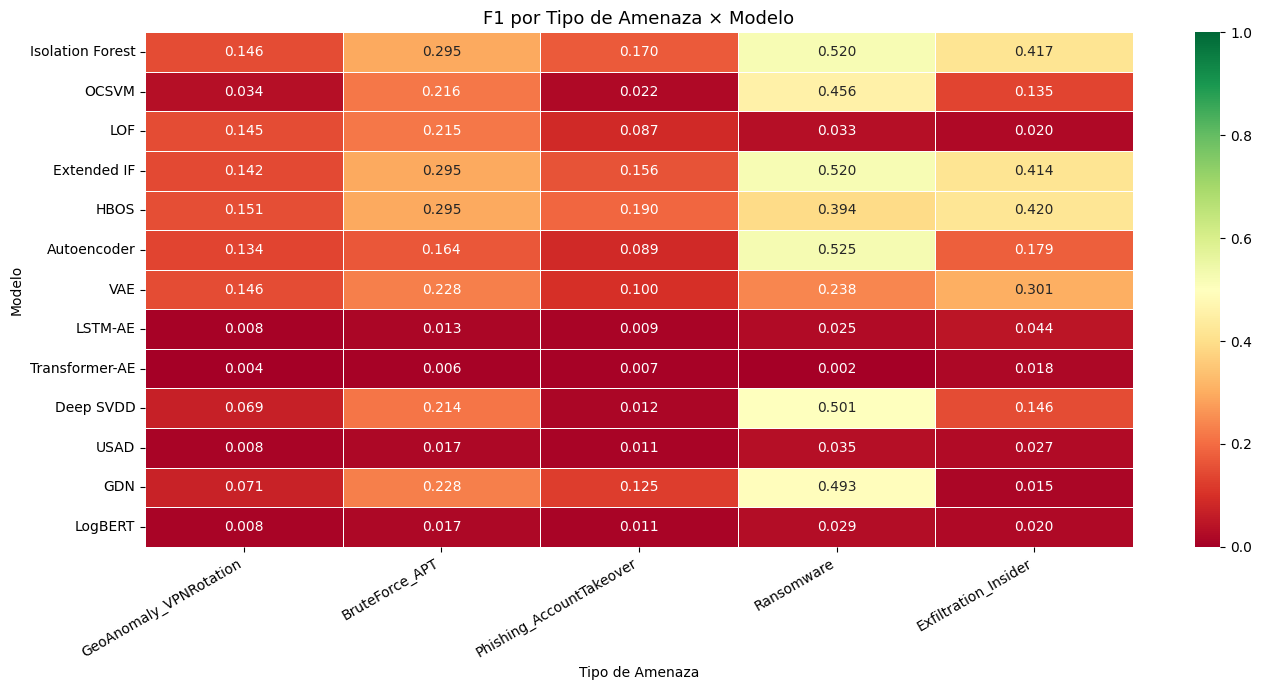

In [22]:
# ── F1 por tipo de amenaza para cada modelo ─────────────────────
threat_metrics = {name: {} for name in results}

for threat in threat_types:
    mask_threat  = (df_eval["ThreatType"] == threat).values
    y_threat     = mask_threat.astype(int)
    for name, r in results.items():
        thr = np.percentile(r["scores_norm"], 95)
        preds = (r["scores_norm"] >= thr).astype(int)
        threat_metrics[name][threat] = f1_score(y_threat, preds, zero_division=0)

df_threat = pd.DataFrame(threat_metrics).T
print(df_threat.to_string(float_format="{:.3f}".format))

# ── Heatmap por amenaza ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(df_threat, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("F1 por Tipo de Amenaza × Modelo", fontsize=13)
ax.set_xlabel("Tipo de Amenaza"); ax.set_ylabel("Modelo")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(DIR_PLOTS / "f1_por_amenaza.png", dpi=150, bbox_inches="tight")
plt.show()


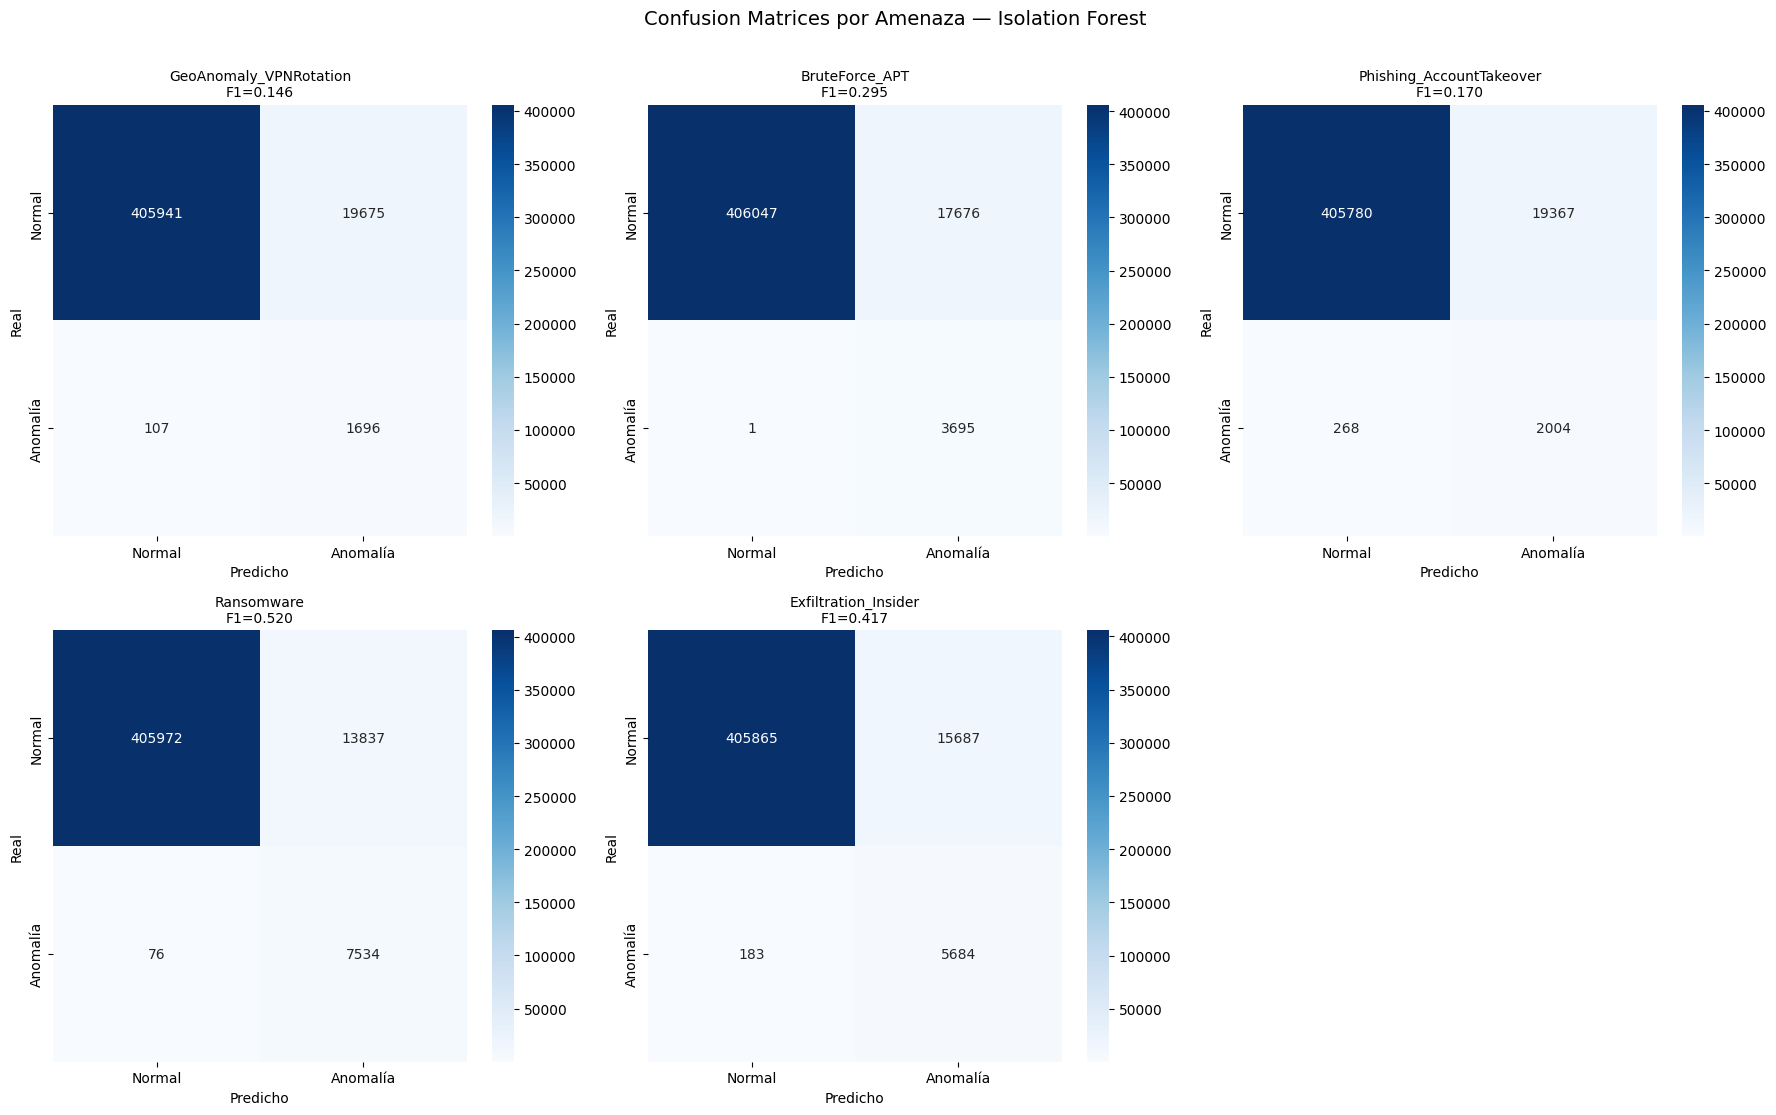

In [23]:
# ── Confusion matrices del mejor modelo ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
best_labels = results[best_model_name]["labels"]

for i, threat in enumerate(threat_types):
    mask_threat = (df_eval["ThreatType"] == threat).values
    y_t = mask_threat.astype(int)
    cm  = confusion_matrix(y_t, best_labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Normal","Anomalía"],
                yticklabels=["Normal","Anomalía"])
    f1_t = f1_score(y_t, best_labels, zero_division=0)
    axes[i].set_title(f"{threat}\nF1={f1_t:.3f}", fontsize=10)
    axes[i].set_xlabel("Predicho"); axes[i].set_ylabel("Real")

# Ocultar el 6º subplot si no hay 6 amenazas
if len(threat_types) < 6:
    for j in range(len(threat_types), 6):
        axes[j].set_visible(False)

fig.suptitle(f"Confusion Matrices por Amenaza — {best_model_name}", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(DIR_PLOTS / "confusion_matrices_amenazas.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Explicabilidad — SHAP

**Referencia**: Lundberg, S.M. & Lee, S.I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 2017.  
**Idea**: SHAP (SHapley Additive exPlanations) asigna a cada feature una contribución a la predicción del modelo para cada instancia individual, basándose en la teoría de juegos cooperativos (valores de Shapley).  
**Por qué es esencial para un TFG de ciberseguridad**: permite responder "¿por qué el modelo marcó este log como anómalo?" — crítico para que un analista de seguridad confíe en el sistema.

### Lo que se analiza
1. **Summary plot**: importancia global de features
2. **Beeswarm plot**: dirección del efecto (valores altos de feature X → ¿más o menos anómalo?)
3. **SHAP por tipo de amenaza**: qué features explican cada ataque


Calculando SHAP para modelos...


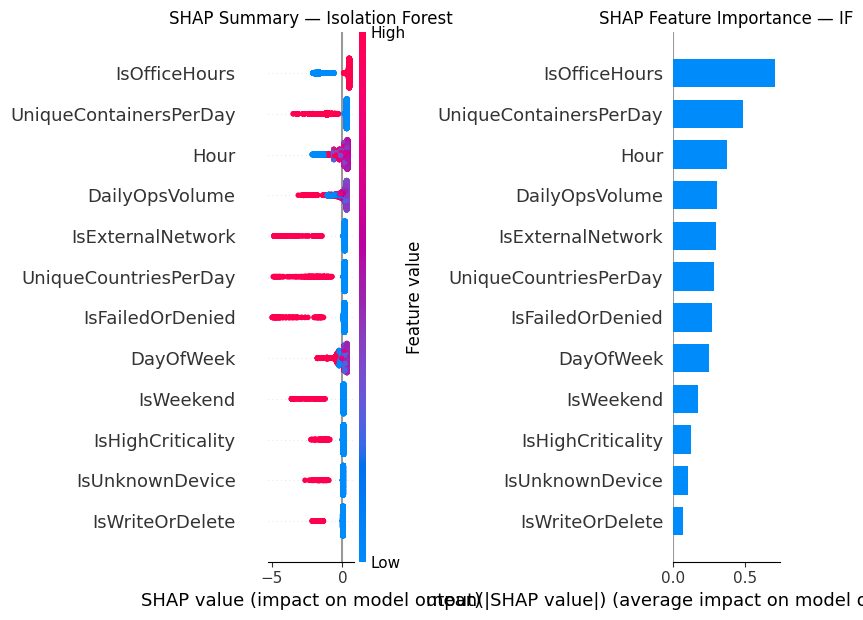

In [24]:
# ── SHAP para el mejor modelo clásico (más interpretable) ───────
# SHAP TreeExplainer funciona directamente con Isolation Forest
# Para modelos DL usamos KernelExplainer con subsample

print(f"Calculando SHAP para modelos...")

# ── SHAP con IF (TreeExplainer — exacto y rápido) ───────────────
explainer_if = shap.TreeExplainer(clf_if)
# Subsample para velocidad
idx_shap = np.random.choice(len(X), size=min(5000, len(X)), replace=False)
X_shap   = X[idx_shap]
shap_values_if = explainer_if.shap_values(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.sca(axes[0])
shap.summary_plot(shap_values_if, X_shap, feature_names=FEATURES,
                  show=False, max_display=12)
axes[0].set_title("SHAP Summary — Isolation Forest", fontsize=12)

plt.sca(axes[1])
shap.summary_plot(shap_values_if, X_shap, feature_names=FEATURES,
                  plot_type="bar", show=False, max_display=12)
axes[1].set_title("SHAP Feature Importance — IF", fontsize=12)

plt.tight_layout()
plt.savefig(DIR_PLOTS / "shap_isolation_forest.png", dpi=150, bbox_inches="tight")
plt.show()


Calculando SHAP KernelExplainer para Autoencoder (subsample 500)...


100%|██████████| 500/500 [00:04<00:00, 105.74it/s]


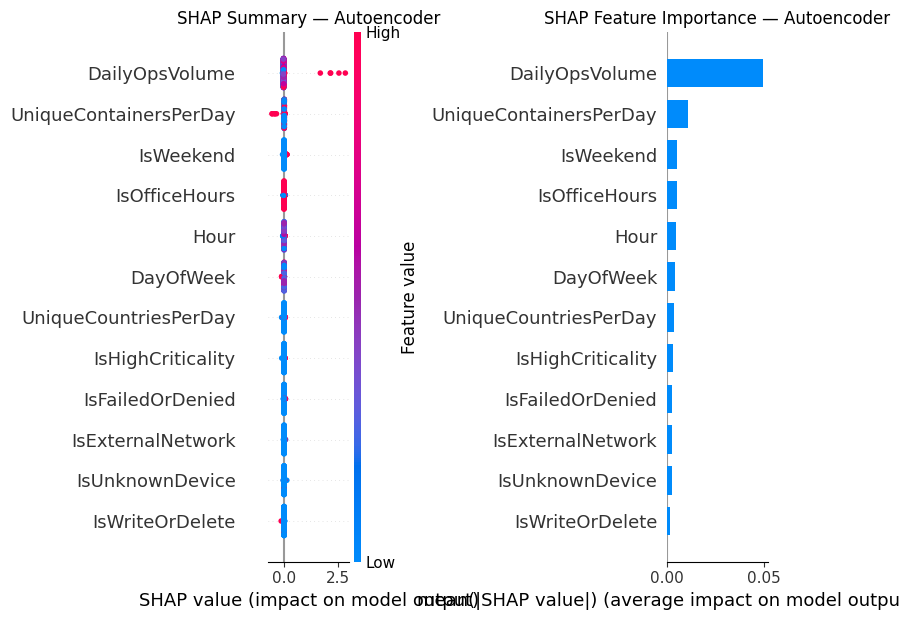

In [25]:
# ── SHAP KernelExplainer para mejor modelo DL ───────────────────
# Usamos subsample pequeño porque KernelExplainer es O(n²)
best_dl_name = df_metrics[df_metrics["Modelo"].isin(
    ["Autoencoder","VAE","Deep SVDD","USAD","LSTM-AE","Transformer-AE","GDN","LogBERT"]
)].iloc[0]["Modelo"]

print(f"Calculando SHAP KernelExplainer para {best_dl_name} (subsample 500)...")

# Función de scoring para KernelExplainer
def model_predict(X_input):
    t = torch.FloatTensor(X_input).to(DEVICE)
    model_map = {
        "Autoencoder": ae, "VAE": vae, "Deep SVDD": svdd_net,
        "USAD": usad, "GDN": gdn
    }
    if best_dl_name in model_map:
        model_dl = model_map[best_dl_name]
        model_dl.eval()
        with torch.no_grad():
            if best_dl_name == "VAE":
                out, _, _ = model_dl(t)
            elif best_dl_name == "Deep SVDD":
                z = model_dl(t)
                c = c_svdd.to(DEVICE)
                return ((z - c)**2).sum(dim=1).sqrt().cpu().numpy()
            elif best_dl_name == "USAD":
                r1, r2, z = model_dl(t)
                z2 = model_dl.encoder(r1)
                r12 = model_dl.decoder2(z2)
                return (0.5*((t-r1)**2).mean(1) + 0.5*((t-r12)**2).mean(1)).cpu().numpy()
            else:
                out = model_dl(t)
            return ((t - out)**2).mean(dim=1).cpu().numpy()
    return np.zeros(len(X_input))

idx_dl   = np.random.choice(len(X), size=500, replace=False)
X_dl_bg  = X[idx_dl[:100]]   # background para KernelExplainer
X_dl_exp = X[idx_dl]

explainer_dl   = shap.KernelExplainer(model_predict, X_dl_bg)
shap_values_dl = explainer_dl.shap_values(X_dl_exp, nsamples=100)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.sca(axes[0])
shap.summary_plot(shap_values_dl, X_dl_exp, feature_names=FEATURES, show=False)
axes[0].set_title(f"SHAP Summary — {best_dl_name}", fontsize=12)

plt.sca(axes[1])
shap.summary_plot(shap_values_dl, X_dl_exp, feature_names=FEATURES,
                  plot_type="bar", show=False)
axes[1].set_title(f"SHAP Feature Importance — {best_dl_name}", fontsize=12)
plt.tight_layout()
plt.savefig(DIR_PLOTS / f"shap_{best_dl_name.lower().replace(' ','_')}.png",
            dpi=150, bbox_inches="tight")
plt.show()


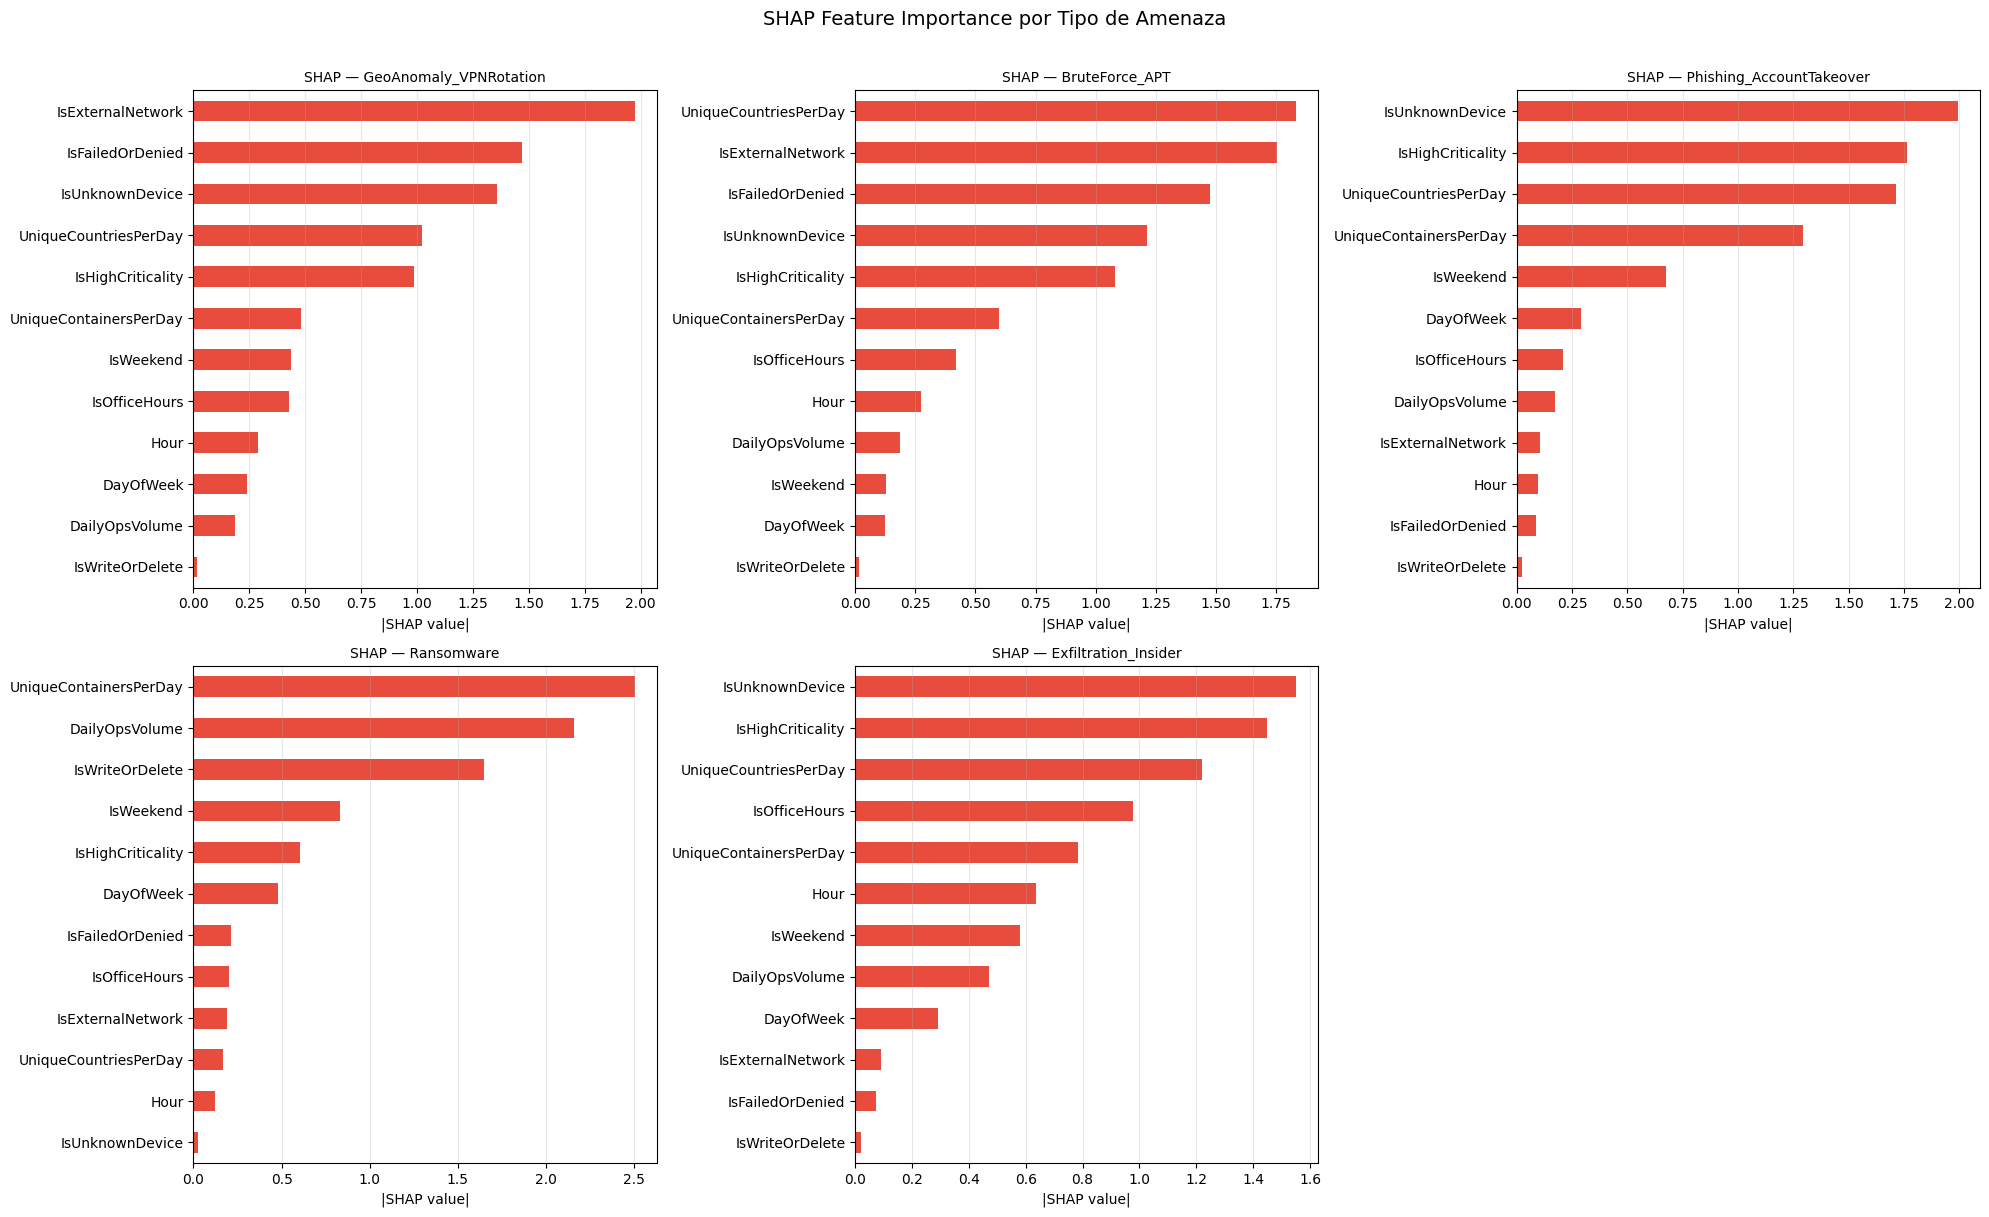

In [26]:
# ── SHAP por tipo de amenaza (usando IF como modelo base) ────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, threat in enumerate(threat_types):
    mask_t  = (df_eval["ThreatType"] == threat).values[idx_shap]
    if mask_t.sum() < 10:
        axes[i].text(0.5, 0.5, f"Pocos ejemplos\n({mask_t.sum()})",
                     ha="center", va="center", transform=axes[i].transAxes)
        axes[i].set_title(threat); continue

    shap_threat = shap_values_if[mask_t]
    mean_abs    = np.abs(shap_threat).mean(axis=0)
    feat_imp    = pd.Series(mean_abs, index=FEATURES).sort_values(ascending=True)

    feat_imp.plot(kind="barh", ax=axes[i], color=COLOR_ANOMALY)
    axes[i].set_title(f"SHAP — {threat}", fontsize=10)
    axes[i].set_xlabel("|SHAP value|")
    axes[i].grid(axis="x", alpha=0.3)

if len(threat_types) < 6:
    for j in range(len(threat_types), 6):
        axes[j].set_visible(False)

plt.suptitle("SHAP Feature Importance por Tipo de Amenaza", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(DIR_PLOTS / "shap_por_amenaza.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Ensemble — Combinación Adaptativa de Modelos

**Idea**: combinar los scores normalizados de todos los modelos para obtener un detector más robusto.  
Se implementan tres estrategias de ensemble:

1. **Promedio simple** (mean): todos los modelos con igual peso
2. **Promedio ponderado por F1** (weighted): los mejores modelos tienen más peso  
3. **Votación por mayoría** (voting): un registro es anómalo si más del 50% de los modelos lo marcan

La literatura reciente (Aggarwal, 2017; Zimek et al., 2014) demuestra que ensembles de detectores de anomalías superan consistentemente a los modelos individuales, especialmente cuando los modelos usan paradigmas distintos (distancia, densidad, reconstrucción, grafo).


In [27]:
# ── Recopilar scores normalizados ───────────────────────────────
score_matrix = np.column_stack([r["scores_norm"] for r in results.values()])
model_names  = list(results.keys())

# ── Ensemble 1: Promedio simple ─────────────────────────────────
scores_mean  = score_matrix.mean(axis=1)
thr_mean     = np.percentile(scores_mean, 95)
labels_mean  = (scores_mean >= thr_mean).astype(int)

# ── Ensemble 2: Ponderado por F1 ────────────────────────────────
f1_weights = np.array([df_metrics[df_metrics["Modelo"]==n]["F1"].values[0]
                       for n in model_names])
f1_weights = np.maximum(f1_weights, 0.01)   # evitar peso 0
f1_weights = f1_weights / f1_weights.sum()

scores_weighted  = (score_matrix * f1_weights).sum(axis=1)
thr_weighted     = np.percentile(scores_weighted, 95)
labels_weighted  = (scores_weighted >= thr_weighted).astype(int)

# ── Ensemble 3: Votación por mayoría ────────────────────────────
label_matrix     = np.column_stack([r["labels"] for r in results.values()])
labels_voting    = (label_matrix.mean(axis=1) > 0.5).astype(int)
scores_voting    = label_matrix.mean(axis=1)

# ── Métricas ensemble ───────────────────────────────────────────
ensemble_results = {
    "Ensemble (Mean)":     {"scores": scores_mean,     "labels": labels_mean,    "scores_norm": scores_mean},
    "Ensemble (Weighted)": {"scores": scores_weighted, "labels": labels_weighted,"scores_norm": scores_weighted},
    "Ensemble (Voting)":   {"scores": scores_voting,   "labels": labels_voting,  "scores_norm": scores_voting},
}
results.update(ensemble_results)

ens_metrics = []
for name, r in ensemble_results.items():
    sn = r["scores_norm"]
    sn = (sn - sn.min()) / (sn.max() - sn.min() + 1e-10)
    ens_metrics.append({
        "Modelo": name,
        "Precision": precision_score(y_true, r["labels"], zero_division=0),
        "Recall":    recall_score(y_true, r["labels"], zero_division=0),
        "F1":        f1_score(y_true, r["labels"], zero_division=0),
        "ROC-AUC":   roc_auc_score(y_true, sn),
        "PR-AUC":    average_precision_score(y_true, sn),
    })

df_ens = pd.DataFrame(ens_metrics)
df_all_metrics = pd.concat([df_metrics[["Modelo","Precision","Recall","F1","ROC-AUC","PR-AUC"]], df_ens],
                            ignore_index=True).sort_values("F1", ascending=False)
print("\n=== RANKING FINAL (incluyendo ensembles) ===")
print(df_all_metrics.to_string(index=False, float_format="{:.4f}".format))



=== RANKING FINAL (incluyendo ensembles) ===
             Modelo  Precision  Recall     F1  ROC-AUC  PR-AUC
   Isolation Forest     0.9645  0.9701 0.9673   0.9992  0.9877
        Extended IF     0.9533  0.9588 0.9561   0.9991  0.9849
Ensemble (Weighted)     0.9402  0.9456 0.9429   0.9990  0.9757
               HBOS     0.8952  0.9002 0.8977   0.9979  0.9678
    Ensemble (Mean)     0.8943  0.8995 0.8969   0.9980  0.9496
        Autoencoder     0.6884  0.6924 0.6904   0.9891  0.7945
  Ensemble (Voting)     0.9513  0.4831 0.6408   0.9971  0.9166
                VAE     0.6218  0.6253 0.6236   0.9839  0.6620
          Deep SVDD     0.6035  0.6066 0.6051   0.8884  0.6485
                GDN     0.5848  0.5881 0.5865   0.9226  0.5943
              OCSVM     0.5604  0.5549 0.5576   0.8916  0.5305
                LOF     0.2882  0.2898 0.2890   0.7031  0.1786
            LSTM-AE     0.0621  0.0625 0.0623   0.5115  0.0523
            LogBERT     0.0529  0.0532 0.0531   0.4902  0.0479
     Tran

## 12. Guardado de Outputs e Informe Final


In [28]:
# ── CSV de predicciones por registro ───────────────────────────
print("Generando CSV de predicciones...")
df_pred = df[["CustomTimestamp","UserPrincipalName","y_true"]].copy()

for name, r in results.items():
    col_safe = name.replace(" ","_").replace("(","").replace(")","")
    df_pred[f"score_{col_safe}"]  = r["scores_norm"] if "scores_norm" in r else r["scores"]
    df_pred[f"label_{col_safe}"]  = r["labels"]

df_pred.to_csv(DIR_RESULTS / "predictions_all_models.csv", index=False)
print(f"predictions_all_models.csv guardado ({len(df_pred):,} registros)")


Generando CSV de predicciones...
predictions_all_models.csv guardado (427,419 registros)


In [29]:
# ── Informe resumen ─────────────────────────────────────────────
best_row = df_all_metrics.iloc[0]

informe = f"""
================================================================
  INFORME DE RESULTADOS — TFG Detección de Anomalías Azure
================================================================

Dataset
  Total registros     : {len(df):,}
  Registros normales  : {(y_true==0).sum():,}
  Registros maliciosos: {(y_true==1).sum():,}
  Contaminación real  : {y_true.mean()*100:.2f}%
  Período             : {df['CustomTimestamp'].min()} → {df['CustomTimestamp'].max()}
  Features ML         : {len(FEATURES)}

Hardware utilizado
  GPU                 : {torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else 'CPU'}
  Device              : {DEVICE}

Modelos evaluados     : {len(df_all_metrics)}

RANKING FINAL (por F1):
{df_all_metrics.to_string(index=False, float_format="{:.4f}".format)}

MEJOR MODELO: {best_row['Modelo']}
  Precision : {best_row['Precision']:.4f}
  Recall    : {best_row['Recall']:.4f}
  F1        : {best_row['F1']:.4f}
  ROC-AUC   : {best_row['ROC-AUC']:.4f}
  PR-AUC    : {best_row['PR-AUC']:.4f}

Outputs generados:
  ../Models/           → modelos entrenados (.pkl / .pt)
  ../Results/predictions_all_models.csv
  ../Results/plots/    → {len(list(DIR_PLOTS.glob('*.png')))} gráficas

================================================================
"""

print(informe)

with open(DIR_RESULTS / "informe_resumen_TFG.txt", "w", encoding="utf-8") as f:
    f.write(informe)
print("Informe guardado en ../Results/informe_resumen_TFG.txt")



  INFORME DE RESULTADOS — TFG Detección de Anomalías Azure

Dataset
  Total registros     : 427,419
  Registros normales  : 406,171
  Registros maliciosos: 21,248
  Contaminación real  : 4.97%
  Período             : 2026-01-01 00:00:26 → 2026-02-11 23:58:47
  Features ML         : 12

Hardware utilizado
  GPU                 : NVIDIA GeForce GTX 1650
  Device              : cuda

Modelos evaluados     : 16

RANKING FINAL (por F1):
             Modelo  Precision  Recall     F1  ROC-AUC  PR-AUC
   Isolation Forest     0.9645  0.9701 0.9673   0.9992  0.9877
        Extended IF     0.9533  0.9588 0.9561   0.9991  0.9849
Ensemble (Weighted)     0.9402  0.9456 0.9429   0.9990  0.9757
               HBOS     0.8952  0.9002 0.8977   0.9979  0.9678
    Ensemble (Mean)     0.8943  0.8995 0.8969   0.9980  0.9496
        Autoencoder     0.6884  0.6924 0.6904   0.9891  0.7945
  Ensemble (Voting)     0.9513  0.4831 0.6408   0.9971  0.9166
                VAE     0.6218  0.6253 0.6236   0.9839  0.6